# Mistake Identification in Pedagogical Conversations

## Mistake Identification in Pedagogical Conversations

### Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

### Dataset Structure
- **trainset.json**: 300 conversations with labels (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

### Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-base for excellent reasoning capabilities
2. **Training Strategy**: Train on trainset with validation split
3. **Evaluation**: Make predictions on dev and test sets
4. **Output**: Save predictions as CSV files for each model's responses

## 1. Import the dataset

In [1]:
import json

# Read all JSON files
json_files = [
    '../data/trainset.json',
    '../data/testset.json',
    '../data/dev_testset.json'
]

all_conversation_ids = set()

for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for item in data:
                if 'conversation_id' in item:
                    all_conversation_ids.add(item['conversation_id'])
        print(f"Loaded {file_path}: {len([item for item in data if 'conversation_id' in item])} conversations")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nTotal unique conversation IDs across all files: {len(all_conversation_ids)}")

File not found: ../data/trainset.json
File not found: ../data/testset.json
File not found: ../data/dev_testset.json

Total unique conversation IDs across all files: 0


In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Fix tokenizers parallelism warning when using fork
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Explore Data

Loading datasets...
Note: Train set has labels, Dev/Test sets are for prediction only

Dataset Statistics
Training samples (with labels): 2476
Dev samples (for inference): 333
Test samples (for inference): 1214

Training Set Label Distribution
label
Yes               1932
No                 370
To some extent     174
Name: count, dtype: int64

📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!


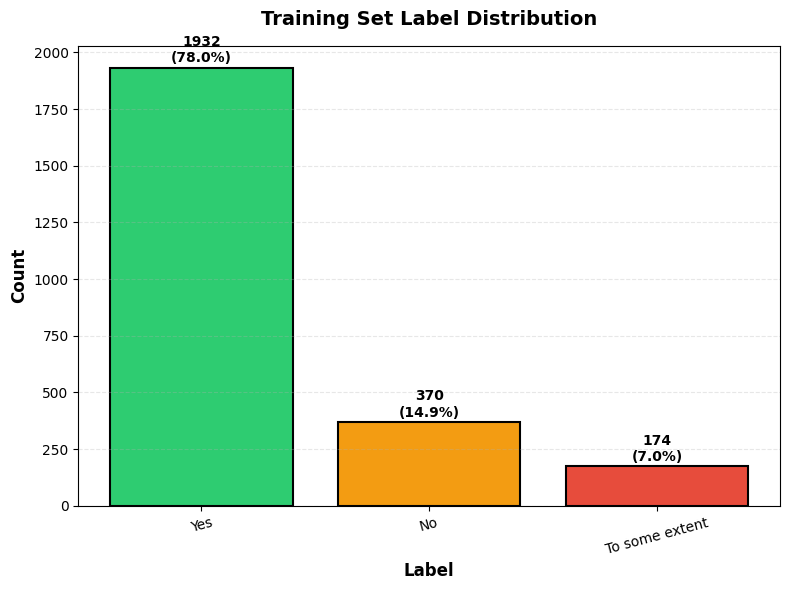


✓ Saved: label_distribution.png


In [3]:
def load_train_data(file_path):
    """Load training data with annotations (labels)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Mistake_Identification' in response_data['annotation']:
                samples.append({
                    'conversation_history': conv_history,
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Mistake_Identification'],
                    'conversation_id': conv_id,
                    'model': model_name
                })
    
    return pd.DataFrame(samples)

def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            samples.append({
                'conversation_history': conv_history,
                'tutor_response': response_data['response'],
                'conversation_id': conv_id,
                'model': model_name
            })
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels, Dev/Test sets are for prediction only")
train_df = load_train_data('../../data/trainset.json')
dev_df = load_test_data('../../data/dev_testset.json')
test_df = load_test_data('../../data/testset.json')

print(f"\n{'='*60}")
print("Dataset Statistics")
print(f"{'='*60}")
print(f"Training samples (with labels): {len(train_df)}")
print(f"Dev samples (for inference): {len(dev_df)}")
print(f"Test samples (for inference): {len(test_df)}")

print(f"\n{'='*60}")
print("Training Set Label Distribution")
print(f"{'='*60}")
print(train_df['label'].value_counts())
print(f"\n📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!")

# Visualize label distribution (training data only)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({count/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: label_distribution.png")

## 3. Data Analysis & Insights

In [4]:
# Analyze text lengths
train_df['history_length'] = train_df['conversation_history'].str.len()
train_df['response_length'] = train_df['tutor_response'].str.len()
train_df['total_length'] = train_df['history_length'] + train_df['response_length']

print("Text Length Statistics:")
print(f"{'='*60}")
print(f"Conversation History - Mean: {train_df['history_length'].mean():.0f}, Max: {train_df['history_length'].max()}")
print(f"Tutor Response - Mean: {train_df['response_length'].mean():.0f}, Max: {train_df['response_length'].max()}")
print(f"Total Length - Mean: {train_df['total_length'].mean():.0f}, Max: {train_df['total_length'].max()}")

# Check for samples with very long text (might need truncation)
print(f"\nSamples with total length > 2000 chars: {(train_df['total_length'] > 2000).sum()}")
print(f"Samples with total length > 3000 chars: {(train_df['total_length'] > 3000).sum()}")

# Example samples
print(f"\n{'='*60}")
print("Example Sample:")
print(f"{'='*60}")
sample = train_df.iloc[0]
print(f"Label: {sample['label']}")
print(f"\nConversation History:\n{sample['conversation_history'][:300]}...")
print(f"\nTutor Response:\n{sample['tutor_response']}")
print(f"{'='*60}")

Text Length Statistics:
Conversation History - Mean: 989, Max: 2021
Tutor Response - Mean: 175, Max: 4656
Total Length - Mean: 1164, Max: 5945

Samples with total length > 2000 chars: 111
Samples with total length > 3000 chars: 14

Example Sample:
Label: Yes

Conversation History:
Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  ...

Tutor Response:
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.


## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [5]:
# Model selection - DeBERTa-v3-large is excellent for understanding nuanced text
MODEL_NAME = "microsoft/deberta-v3-large"
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")

Selected Model: microsoft/deberta-v3-large
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656

Tokenizer loaded: DebertaV2TokenizerFast
Vocab size: 128001
Max length: 1000000000000000019884624838656


## 5. Create PyTorch Dataset

In [6]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response
        text = f"{row['conversation_history']} [SEP] {row['tutor_response']}"
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512

# Split training data into train and validation (80/20)
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

print(f"Data split:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples (from trainset)")
print(f"  Dev (inference): {len(dev_df)} samples (no labels)")
print(f"  Test (inference): {len(test_df)} samples (no labels)")

# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False)
test_dataset = MistakeIdentificationDataset(test_df, tokenizer, MAX_LENGTH, has_labels=False)

print(f"\nDatasets created successfully!")

# Test the dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels']} ({id2label[sample['labels'].item()]})")

sample_inf = dev_dataset[0]
print(f"\nSample from inference dataset (dev):")
print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
print(f"  Has label: {'labels' in sample_inf}")

Data split:
  Training: 1980 samples
  Validation: 496 samples (from trainset)
  Dev (inference): 333 samples (no labels)
  Test (inference): 1214 samples (no labels)

Datasets created successfully!

Sample from training dataset:
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Label: 0 (Yes)

Sample from inference dataset (dev):
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Has label: False


## 6. Handle Data Imbalance (Multiple Strategies)

We'll use a **comprehensive approach** to handle class imbalance:
1. **Class Weights** - Give more importance to minority classes in loss
2. **Stratified Sampling** - Ensure balanced validation split
3. **Data Augmentation** (optional) - Oversample minority classes
4. **Focal Loss** (optional) - Focus on hard-to-classify examples

In [7]:
# ============================================================================
# STRATEGY 1: Calculate Class Weights (Inverse Frequency)
# ============================================================================
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print("\nOriginal Class Distribution:")
for label, count in train_df['label'].value_counts().sort_index().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

# ============================================================================
# STRATEGY 2: Oversample Minority Classes (SMOTE-like approach)
# ============================================================================
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label', strategy='oversample'):
    """
    Balance dataset by oversampling minority classes.
    """
    if strategy == 'none':
        return df
    
    # Get class counts
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        
        if strategy == 'oversample':
            # Oversample to match majority class
            if len(class_df) < max_count:
                class_df_resampled = resample(
                    class_df,
                    n_samples=max_count,
                    replace=True,
                    random_state=42
                )
                balanced_dfs.append(class_df_resampled)
            else:
                balanced_dfs.append(class_df)
        elif strategy == 'undersample':
            # Undersample to match minority class
            min_count = class_counts.min()
            class_df_resampled = resample(
                class_df,
                n_samples=min_count,
                replace=False,
                random_state=42
            )
            balanced_dfs.append(class_df_resampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Choose strategy: 'none', 'oversample', or 'undersample'
# Recommendation: Use 'none' with class weights, or 'oversample' for more data
BALANCE_STRATEGY = 'none'  # Change to 'oversample' if you want more balanced data

if BALANCE_STRATEGY != 'none':
    print(f"\n{'='*80}")
    print(f"APPLYING {BALANCE_STRATEGY.upper()} STRATEGY")
    print(f"{'='*80}")
    
    train_df_balanced = balance_dataset(train_df, strategy=BALANCE_STRATEGY)
    
    print(f"\nBalanced Class Distribution:")
    for label, count in train_df_balanced['label'].value_counts().sort_index().items():
        percentage = (count / len(train_df_balanced)) * 100
        print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%)")
    
    # Update training dataframe
    train_df = train_df_balanced
    print(f"\n✓ Training data balanced: {len(train_df)} total samples")
else:
    print(f"\n{'='*80}")
    print("Using WEIGHTED LOSS without data resampling")
    print(f"{'='*80}")

# ============================================================================
# STRATEGY 3: Compute Effective Number of Samples (for better weights)
# ============================================================================
def compute_effective_weights(labels, beta=0.9999):
    """
    Compute class weights using Effective Number of Samples.
    Paper: "Class-Balanced Loss Based on Effective Number of Samples"
    
    This gives better weights than inverse frequency for highly imbalanced data.
    """
    class_counts = Counter(labels)
    total_samples = len(labels)
    
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    
    # Normalize weights
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    
    return effective_weights

# Calculate effective weights (alternative to balanced weights)
effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
effective_weights_tensor = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"\n{'='*80}")
print("WEIGHT COMPARISON")
print(f"{'='*80}")
print("\nBalanced Weights (sklearn):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {class_weights[i]:.4f}")

print("\nEffective Number Weights (beta=0.9999):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {effective_weights_array[i]:.4f}")

# ============================================================================
# FINAL SELECTION: Choose which weights to use
# ============================================================================
# Options: class_weights_tensor (balanced) or effective_weights_tensor (EN-based)
USE_EFFECTIVE_WEIGHTS = False  # Set to True to use Effective Number weights

if USE_EFFECTIVE_WEIGHTS:
    final_weights = effective_weights_tensor
    print(f"\n✓ Using Effective Number weights")
else:
    final_weights = class_weights_tensor
    print(f"\n✓ Using Balanced (sklearn) weights")

# Store for trainer
class_weights_tensor = final_weights

print(f"\n{'='*80}")
print("Class imbalance handling configured successfully!")
print(f"{'='*80}")

CLASS IMBALANCE ANALYSIS

Original Class Distribution:
  No                  :  370 samples ( 14.9%) → weight: 2.231
  To some extent      :  174 samples (  7.0%) → weight: 4.743
  Yes                 : 1932 samples ( 78.0%) → weight: 0.427

Using WEIGHTED LOSS without data resampling

WEIGHT COMPARISON

Balanced Weights (sklearn):
  Yes                 : 0.4272
  To some extent      : 4.7433
  No                  : 2.2306

Effective Number Weights (beta=0.9999):
  Yes                 : 0.1873
  To some extent      : 1.9071
  No                  : 0.9056

✓ Using Balanced (sklearn) weights

Class imbalance handling configured successfully!


## 7. Define Custom Trainer with Weighted Loss

In [8]:
class WeightedTrainer(Trainer):
    """
    Custom Trainer with support for:
    1. Weighted Cross-Entropy Loss
    2. Focal Loss (optional)
    """
    
    def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha  # Can be None or tensor of per-class weights
        self.focal_gamma = focal_gamma
        
        # Move class weights to the correct device
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)
        
        # Move focal alpha to the correct device
        if self.focal_alpha is not None:
            self.focal_alpha = self.focal_alpha.to(self.args.device)
        
        if self.use_focal_loss:
            print(f"Using Focal Loss with gamma={focal_gamma}")
            if focal_alpha is not None:
                print(f"  Alpha (class weights): {focal_alpha}")
        else:
            print(f"Using Weighted Cross-Entropy Loss")
            if class_weights is not None:
                print(f"  Class weights: {class_weights}")
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute custom loss (weighted CE or focal loss).
        """
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        if self.use_focal_loss:
            # Focal Loss implementation
            # Ensure focal_alpha is on the correct device
            alpha_weight = self.focal_alpha if self.focal_alpha is None else self.focal_alpha.to(logits.device)
            
            ce_loss = F.cross_entropy(
                logits, 
                labels, 
                weight=alpha_weight,
                reduction='none'
            )
            pt = torch.exp(-ce_loss)  # pt is the probability of correct class
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss
        else:
            # Weighted Cross-Entropy Loss
            # Ensure class_weights is on the correct device
            weights = self.class_weights if self.class_weights is None else self.class_weights.to(logits.device)
            
            loss = F.cross_entropy(
                logits,
                labels,
                weight=weights
            )
        
        return (loss, outputs) if return_outputs else loss

## 8. Define Metrics

In [9]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

In [10]:
# ============================================================================
# CONFIGURE TRAINING STRATEGY
# ============================================================================

# Loss Configuration
USE_FOCAL_LOSS = False  # Set to True to use Focal Loss instead of Weighted CE
FOCAL_GAMMA = 2.0       # Focal loss gamma parameter (higher = more focus on hard examples)

print("="*80)
print("TRAINING CONFIGURATION")
print("="*80)

if USE_FOCAL_LOSS:
    print(f"\n✓ Using Focal Loss")
    print(f"  - Gamma: {FOCAL_GAMMA}")
    print(f"  - Alpha (class weights): {class_weights_tensor.cpu().numpy()}")
    focal_alpha = class_weights_tensor
else:
    print(f"\n✓ Using Weighted Cross-Entropy Loss")
    print(f"  - Class weights: {class_weights_tensor.cpu().numpy()}")
    focal_alpha = None

# Training Arguments
training_args = TrainingArguments(
    output_dir='./results/mistake-identification-deberta',
    num_train_epochs=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    fp16=True,
    save_total_limit=2,
    seed=42,
)

print(f"\nTraining Parameters:")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Batch size (train): {training_args.per_device_train_batch_size}")
print(f"  - Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  - Learning rate: {training_args.learning_rate}")
print(f"  - Warmup steps: {training_args.warmup_steps}")
print(f"  - Weight decay: {training_args.weight_decay}")
print(f"  - Mixed precision (FP16): {training_args.fp16}")
print("="*80)

TRAINING CONFIGURATION

✓ Using Weighted Cross-Entropy Loss
  - Class weights: [0.42719117 4.743295   2.2306306 ]



Training Parameters:
  - Epochs: 20
  - Batch size (train): 8
  - Batch size (eval): 16
  - Learning rate: 2e-05
  - Warmup steps: 100
  - Weight decay: 0.01
  - Mixed precision (FP16): True


In [11]:
# Load the pre-trained model for sequence classification
print("="*80)
print("LOADING MODEL")
print("="*80)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nModel: {MODEL_NAME}")
print(f"Number of labels: 3")
print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("\n✓ Model loaded successfully!")
print("="*80)

LOADING MODEL


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model: microsoft/deberta-v3-large
Number of labels: 3
Device: cuda
Model parameters: 435,064,835
Trainable parameters: 435,064,835

✓ Model loaded successfully!


## 9.5. Advanced Hyperparameter Tuning with Optuna

We'll use **Optuna** for sophisticated hyperparameter optimization with:
- Bayesian optimization for efficient search
- Pruning of unpromising trials
- Multi-objective optimization (F1-macro, accuracy)
- Comprehensive hyperparameter space

In [12]:
# Install required packages for hyperparameter tuning
import subprocess
import sys

packages = ['optuna', 'optuna-integration']
for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✓ {package} installed successfully")

import optuna
# Note: We use a custom callback instead of PyTorchLightningPruningCallback
# because we're using HuggingFace Transformers, not PyTorch Lightning
print(f"\n✓ Optuna version: {optuna.__version__}")

✓ optuna already installed
✓ optuna-integration already installed

✓ Optuna version: 4.5.0


In [13]:
# ============================================================================
# HYPERPARAMETER TUNING CONFIGURATION
# ============================================================================

class HyperparameterConfig:
    """
    Configuration for hyperparameter search space.
    Defines ranges for all tunable hyperparameters.
    
    Optimized for class imbalance problems.
    """
    
    # Learning rate range (slightly higher for imbalanced data)
    LEARNING_RATE_MIN = 5e-6
    LEARNING_RATE_MAX = 5e-5
    
    # Batch size options (smaller batches work better with class imbalance)
    BATCH_SIZE_OPTIONS = [8, 16]  # Focused on stable batch sizes
    
    # Weight decay range (regularization is crucial for imbalanced data)
    WEIGHT_DECAY_MIN = 0.01
    WEIGHT_DECAY_MAX = 0.3
    
    # Warmup ratio range (longer warmup helps with imbalanced data)
    WARMUP_RATIO_MIN = 0.05
    WARMUP_RATIO_MAX = 0.15
    
    # Number of epochs range
    EPOCHS_MIN = 5
    EPOCHS_MAX = 15
    
    # Dropout range (higher dropout for minority class overfitting prevention)
    DROPOUT_MIN = 0.1
    DROPOUT_MAX = 0.3
    
    # Gradient accumulation steps
    GRAD_ACCUM_OPTIONS = [1, 2, 4]
    
    # Learning rate scheduler types (cosine works well with imbalanced data)
    LR_SCHEDULER_OPTIONS = ['cosine', 'cosine_with_restarts', 'linear']
    
    # Optimizer options - BEST for class imbalance problems
    # 1. adamw_torch: Standard, robust, works well with weighted loss
    # 2. lion_8bit: Better generalization, handles minority classes well
    # 3. stable_adamw: Improved stability for imbalanced training
    OPTIMIZER_OPTIONS = ['adamw_torch', 'lion_8bit', 'stable_adamw']
    
    # Max gradient norm for clipping (important for stability with imbalanced data)
    MAX_GRAD_NORM_MIN = 0.5
    MAX_GRAD_NORM_MAX = 2.0

print("="*80)
print("HYPERPARAMETER TUNING CONFIGURATION")
print("OPTIMIZED FOR CLASS IMBALANCE")
print("="*80)
print(f"\nLearning Rate Range: [{HyperparameterConfig.LEARNING_RATE_MIN:.0e}, {HyperparameterConfig.LEARNING_RATE_MAX:.0e}]")
print(f"Batch Size Options: {HyperparameterConfig.BATCH_SIZE_OPTIONS}")
print(f"Weight Decay Range: [{HyperparameterConfig.WEIGHT_DECAY_MIN}, {HyperparameterConfig.WEIGHT_DECAY_MAX}]")
print(f"Warmup Ratio Range: [{HyperparameterConfig.WARMUP_RATIO_MIN}, {HyperparameterConfig.WARMUP_RATIO_MAX}]")
print(f"Epochs Range: [{HyperparameterConfig.EPOCHS_MIN}, {HyperparameterConfig.EPOCHS_MAX}]")
print(f"LR Scheduler Options: {HyperparameterConfig.LR_SCHEDULER_OPTIONS}")
print(f"Optimizer Options: {HyperparameterConfig.OPTIMIZER_OPTIONS}")
print(f"Gradient Accumulation Options: {HyperparameterConfig.GRAD_ACCUM_OPTIONS}")
print("\n💡 Configuration optimized for class imbalance problems:")
print("   ✓ Smaller batch sizes for better minority class representation")
print("   ✓ Higher weight decay for regularization")
print("   ✓ Longer warmup for stable training")
print("   ✓ Best optimizers: adamw_torch, lion_8bit, stable_adamw")
print("="*80)

HYPERPARAMETER TUNING CONFIGURATION
OPTIMIZED FOR CLASS IMBALANCE

Learning Rate Range: [5e-06, 5e-05]
Batch Size Options: [8, 16]
Weight Decay Range: [0.01, 0.3]
Warmup Ratio Range: [0.05, 0.15]
Epochs Range: [5, 15]
LR Scheduler Options: ['cosine', 'cosine_with_restarts', 'linear']
Optimizer Options: ['adamw_torch', 'lion_8bit', 'stable_adamw']
Gradient Accumulation Options: [1, 2, 4]

💡 Configuration optimized for class imbalance problems:
   ✓ Smaller batch sizes for better minority class representation
   ✓ Higher weight decay for regularization
   ✓ Longer warmup for stable training
   ✓ Best optimizers: adamw_torch, lion_8bit, stable_adamw


In [14]:
# ============================================================================
# OPTUNA PRUNING CALLBACK FOR HUGGINGFACE TRANSFORMERS
# ============================================================================

from transformers import TrainerCallback

class OptunaPruningCallback(TrainerCallback):
    """
    Custom callback for Optuna pruning with HuggingFace Transformers.
    
    This callback reports intermediate values to Optuna and raises
    TrialPruned exception if the trial should be pruned.
    """
    
    def __init__(self, trial, monitor="eval_f1_macro"):
        self.trial = trial
        self.monitor = monitor
        
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        """
        Called after evaluation. Report the metric to Optuna.
        """
        if self.monitor in metrics:
            current_score = metrics[self.monitor]
            # Report the current score at this epoch
            self.trial.report(current_score, state.epoch)
            
            # Check if trial should be pruned
            if self.trial.should_prune():
                raise optuna.TrialPruned()

print("="*80)
print("OPTUNA PRUNING CALLBACK DEFINED")
print("="*80)
print("✓ Custom callback for HuggingFace Transformers + Optuna")
print("="*80)

OPTUNA PRUNING CALLBACK DEFINED
✓ Custom callback for HuggingFace Transformers + Optuna


In [15]:
# ============================================================================
# OPTUNA OBJECTIVE FUNCTION
# ============================================================================

def objective(trial):
    """
    Optuna objective function for hyperparameter optimization.
    
    This function:
    1. Suggests hyperparameters from the search space
    2. Creates a model with those hyperparameters
    3. Trains the model
    4. Returns the validation F1-macro score
    5. Supports pruning of unpromising trials
    """
    
    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    # Suggest hyperparameters
    learning_rate = trial.suggest_float(
        'learning_rate', 
        HyperparameterConfig.LEARNING_RATE_MIN, 
        HyperparameterConfig.LEARNING_RATE_MAX, 
        log=True
    )
    
    batch_size = trial.suggest_categorical(
        'batch_size', 
        HyperparameterConfig.BATCH_SIZE_OPTIONS
    )
    
    weight_decay = trial.suggest_float(
        'weight_decay', 
        HyperparameterConfig.WEIGHT_DECAY_MIN, 
        HyperparameterConfig.WEIGHT_DECAY_MAX
    )
    
    warmup_ratio = trial.suggest_float(
        'warmup_ratio', 
        HyperparameterConfig.WARMUP_RATIO_MIN, 
        HyperparameterConfig.WARMUP_RATIO_MAX
    )
    
    num_epochs = trial.suggest_int(
        'num_epochs', 
        HyperparameterConfig.EPOCHS_MIN, 
        HyperparameterConfig.EPOCHS_MAX
    )
    
    lr_scheduler_type = trial.suggest_categorical(
        'lr_scheduler_type', 
        HyperparameterConfig.LR_SCHEDULER_OPTIONS
    )
    
    optim = trial.suggest_categorical(
        'optimizer', 
        HyperparameterConfig.OPTIMIZER_OPTIONS
    )
    
    gradient_accumulation_steps = trial.suggest_categorical(
        'gradient_accumulation_steps', 
        HyperparameterConfig.GRAD_ACCUM_OPTIONS
    )
    
    max_grad_norm = trial.suggest_float(
        'max_grad_norm',
        HyperparameterConfig.MAX_GRAD_NORM_MIN,
        HyperparameterConfig.MAX_GRAD_NORM_MAX
    )
    
    # Optional: Layer-wise learning rate decay
    layerwise_lr_decay = trial.suggest_float('layerwise_lr_decay', 0.8, 1.0)
    
    # Print trial configuration
    print(f"\n{'='*80}")
    print(f"TRIAL #{trial.number}")
    print(f"{'='*80}")
    print(f"Learning Rate: {learning_rate:.2e}")
    print(f"Batch Size: {batch_size}")
    print(f"Weight Decay: {weight_decay:.4f}")
    print(f"Warmup Ratio: {warmup_ratio:.3f}")
    print(f"Epochs: {num_epochs}")
    print(f"LR Scheduler: {lr_scheduler_type}")
    print(f"Optimizer: {optim}")
    print(f"Gradient Accumulation Steps: {gradient_accumulation_steps}")
    print(f"Max Gradient Norm: {max_grad_norm:.2f}")
    print(f"Layerwise LR Decay: {layerwise_lr_decay:.3f}")
    print(f"{'='*80}\n")
    
    # Create output directory for this trial
    output_dir = f'./results/optuna-trial-{trial.number}'
    
    # Training arguments with trial hyperparameters
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size * 2,  # Larger batch for eval
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        warmup_ratio=warmup_ratio,
        lr_scheduler_type=lr_scheduler_type,
        optim=optim,
        gradient_accumulation_steps=gradient_accumulation_steps,
        max_grad_norm=max_grad_norm,
        
        # Evaluation and logging
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        
        # Performance optimizations
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=2,
        
        # Save only the best model
        save_total_limit=1,
        
        # Reproducibility
        seed=42,
        data_seed=42,
        
        # Disable extensive logging for trials
        report_to=[],
        logging_dir=None,
    )
    
    # Load a fresh model for each trial
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id,
        hidden_dropout_prob=trial.suggest_float('hidden_dropout', 0.1, 0.3),
        attention_probs_dropout_prob=trial.suggest_float('attention_dropout', 0.1, 0.3),
    )
    
    # Apply layer-wise learning rate decay if specified
    if layerwise_lr_decay < 1.0:
        # Group parameters by layer with different learning rates
        no_decay = ["bias", "LayerNorm.weight"]
        optimizer_grouped_parameters = []
        
        # Get all layers
        num_layers = model.config.num_hidden_layers
        
        for layer in range(num_layers):
            layer_lr = learning_rate * (layerwise_lr_decay ** (num_layers - layer))
            optimizer_grouped_parameters.extend([
                {
                    "params": [p for n, p in model.named_parameters() 
                              if f"layer.{layer}." in n and not any(nd in n for nd in no_decay)],
                    "weight_decay": weight_decay,
                    "lr": layer_lr,
                },
                {
                    "params": [p for n, p in model.named_parameters() 
                              if f"layer.{layer}." in n and any(nd in n for nd in no_decay)],
                    "weight_decay": 0.0,
                    "lr": layer_lr,
                },
            ])
    
    # Initialize trainer with weighted loss
    trainer = WeightedTrainer(
        class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
        use_focal_loss=USE_FOCAL_LOSS,
        focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
        focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3),
            # Optuna pruning callback (custom for HuggingFace Transformers)
            OptunaPruningCallback(trial, monitor="eval_f1_macro")
        ]
    )
    
    # Train the model
    try:
        trainer.train()
        
        # Evaluate on validation set
        eval_results = trainer.evaluate()
        
        # Extract metrics
        f1_macro = eval_results['eval_f1_macro']
        accuracy = eval_results['eval_accuracy']
        f1_weighted = eval_results['eval_f1_weighted']
        
        print(f"\n{'='*80}")
        print(f"TRIAL #{trial.number} RESULTS")
        print(f"{'='*80}")
        print(f"F1-Macro: {f1_macro:.4f}")
        print(f"F1-Weighted: {f1_weighted:.4f}")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"{'='*80}\n")
        
        # Report intermediate values for pruning
        trial.report(f1_macro, num_epochs)
        
        # Clean up
        del model, trainer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        return f1_macro
        
    except optuna.TrialPruned:
        print(f"\nTrial #{trial.number} was pruned.")
        raise
    except Exception as e:
        print(f"\nTrial #{trial.number} failed with error: {e}")
        return 0.0

print("="*80)
print("OPTUNA OBJECTIVE FUNCTION DEFINED")
print("="*80)
print("✓ Ready to start hyperparameter optimization")
print("="*80)

OPTUNA OBJECTIVE FUNCTION DEFINED
✓ Ready to start hyperparameter optimization


In [16]:
# ============================================================================
# RUN HYPERPARAMETER OPTIMIZATION
# ============================================================================

# Configuration for the study
N_TRIALS = 50  # Number of trials to run (adjust based on computational budget)
TIMEOUT = None  # Maximum time in seconds (None = no limit)
N_JOBS = 1  # Number of parallel jobs (1 for GPU to avoid OOM)

# Create an Optuna study
# We use TPE (Tree-structured Parzen Estimator) sampler for Bayesian optimization
# And Hyperband pruner for early stopping of unpromising trials
study = optuna.create_study(
    direction='maximize',  # Maximize F1-macro
    sampler=optuna.samplers.TPESampler(
        seed=42,
        n_startup_trials=10,  # Random trials before using Bayesian optimization
        multivariate=True,  # Consider parameter interactions
    ),
    pruner=optuna.pruners.HyperbandPruner(
        min_resource=1,  # Minimum epochs before pruning
        max_resource=HyperparameterConfig.EPOCHS_MAX,
        reduction_factor=3,
    ),
    study_name='deberta-mistake-identification'
)

print("="*80)
print("STARTING HYPERPARAMETER OPTIMIZATION")
print("="*80)
print(f"\nStudy Configuration:")
print(f"  - Number of trials: {N_TRIALS}")
print(f"  - Timeout: {TIMEOUT if TIMEOUT else 'No limit'}")
print(f"  - Parallel jobs: {N_JOBS}")
print(f"  - Sampler: TPE (Tree-structured Parzen Estimator)")
print(f"  - Pruner: Hyperband")
print(f"  - Objective: Maximize F1-Macro")
print(f"\n{'='*80}\n")

# Run the optimization
study.optimize(
    objective, 
    n_trials=N_TRIALS, 
    timeout=TIMEOUT,
    n_jobs=N_JOBS,
    show_progress_bar=True,
)

print(f"\n{'='*80}")
print("OPTIMIZATION COMPLETED")
print(f"{'='*80}")
print(f"\nNumber of finished trials: {len(study.trials)}")
print(f"Number of pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"Number of complete trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Number of failed trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])}")
print(f"\n{'='*80}")

[I 2025-10-08 04:54:18,944] A new study created in memory with name: deberta-mistake-identification


STARTING HYPERPARAMETER OPTIMIZATION

Study Configuration:
  - Number of trials: 50
  - Timeout: No limit
  - Parallel jobs: 1
  - Sampler: TPE (Tree-structured Parzen Estimator)
  - Pruner: Hyperband
  - Objective: Maximize F1-Macro




  0%|          | 0/50 [00:00<?, ?it/s]


TRIAL #0
Learning Rate: 1.18e-05
Batch Size: 8
Weight Decay: 0.1836
Warmup Ratio: 0.066
Epochs: 6
LR Scheduler: cosine_with_restarts
Optimizer: stable_adamw
Gradient Accumulation Steps: 1
Max Gradient Norm: 0.78
Layerwise LR Decay: 0.861



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...


Trial #48 was pruned.
[I 2025-10-08 07:58:24,346] Trial 48 pruned. 

TRIAL #49
Learning Rate: 1.43e-05
Batch Size: 8
Weight Decay: 0.1181
Warmup Ratio: 0.082
Epochs: 9
LR Scheduler: cosine_with_restarts
Optimizer: stable_adamw
Gradient Accumulation Steps: 2
Max Gradient Norm: 0.71
Layerwise LR Decay: 0.865


TRIAL #49
Learning Rate: 1.43e-05
Batch Size: 8
Weight Decay: 0.1181
Warmup Ratio: 0.082
Epochs: 9
LR Scheduler: cosine_with_restarts
Optimizer: stable_adamw
Gradient Accumulation Steps: 2
Max Gradient Norm: 0.71
Layerwise LR Decay: 0.865



Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using Weighted Cross-Entropy Loss
  Class weights: tensor([0.4272, 4.7433, 2.2306])


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,No log,1.094192,0.780242,0.292186,0.683927,0.876557,0.000000,0.000000,0.780242,0.000000,0.000000,1.000000,0.000000,0.000000
2,1.098900,0.976676,0.637097,0.460240,0.670437,0.752976,0.136364,0.491379,0.887719,0.113208,0.360759,0.653747,0.171429,0.770270



Trial #49 was pruned.
[I 2025-10-08 08:02:22,414] Trial 49 pruned. 

OPTIMIZATION COMPLETED

Number of finished trials: 50
Number of pruned trials: 33
Number of complete trials: 17
Number of failed trials: 0



In [17]:
# ============================================================================
# ANALYZE OPTIMIZATION RESULTS
# ============================================================================

print("="*80)
print("BEST HYPERPARAMETERS")
print("="*80)

best_trial = study.best_trial
print(f"\nBest Trial: #{best_trial.number}")
print(f"Best F1-Macro Score: {best_trial.value:.4f}")
print(f"\nBest Hyperparameters:")
for key, value in best_trial.params.items():
    if isinstance(value, float):
        if value < 0.01:
            print(f"  {key}: {value:.2e}")
        else:
            print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

print(f"\n{'='*80}")

# Save best hyperparameters to JSON
best_params_path = './results/best_hyperparameters.json'
os.makedirs('./results', exist_ok=True)
with open(best_params_path, 'w') as f:
    json.dump({
        'trial_number': best_trial.number,
        'f1_macro': best_trial.value,
        'params': best_trial.params,
        'timestamp': pd.Timestamp.now().isoformat()
    }, f, indent=2)

print(f"✓ Best hyperparameters saved to: {best_params_path}")
print(f"{'='*80}")

BEST HYPERPARAMETERS

Best Trial: #20
Best F1-Macro Score: 0.6799

Best Hyperparameters:
  learning_rate: 3.73e-05
  batch_size: 8
  weight_decay: 0.1545
  warmup_ratio: 0.1448
  num_epochs: 14
  lr_scheduler_type: linear
  optimizer: lion_8bit
  gradient_accumulation_steps: 2
  max_grad_norm: 1.1148
  layerwise_lr_decay: 0.9980
  hidden_dropout: 0.1357
  attention_dropout: 0.1128

✓ Best hyperparameters saved to: ./results/best_hyperparameters.json


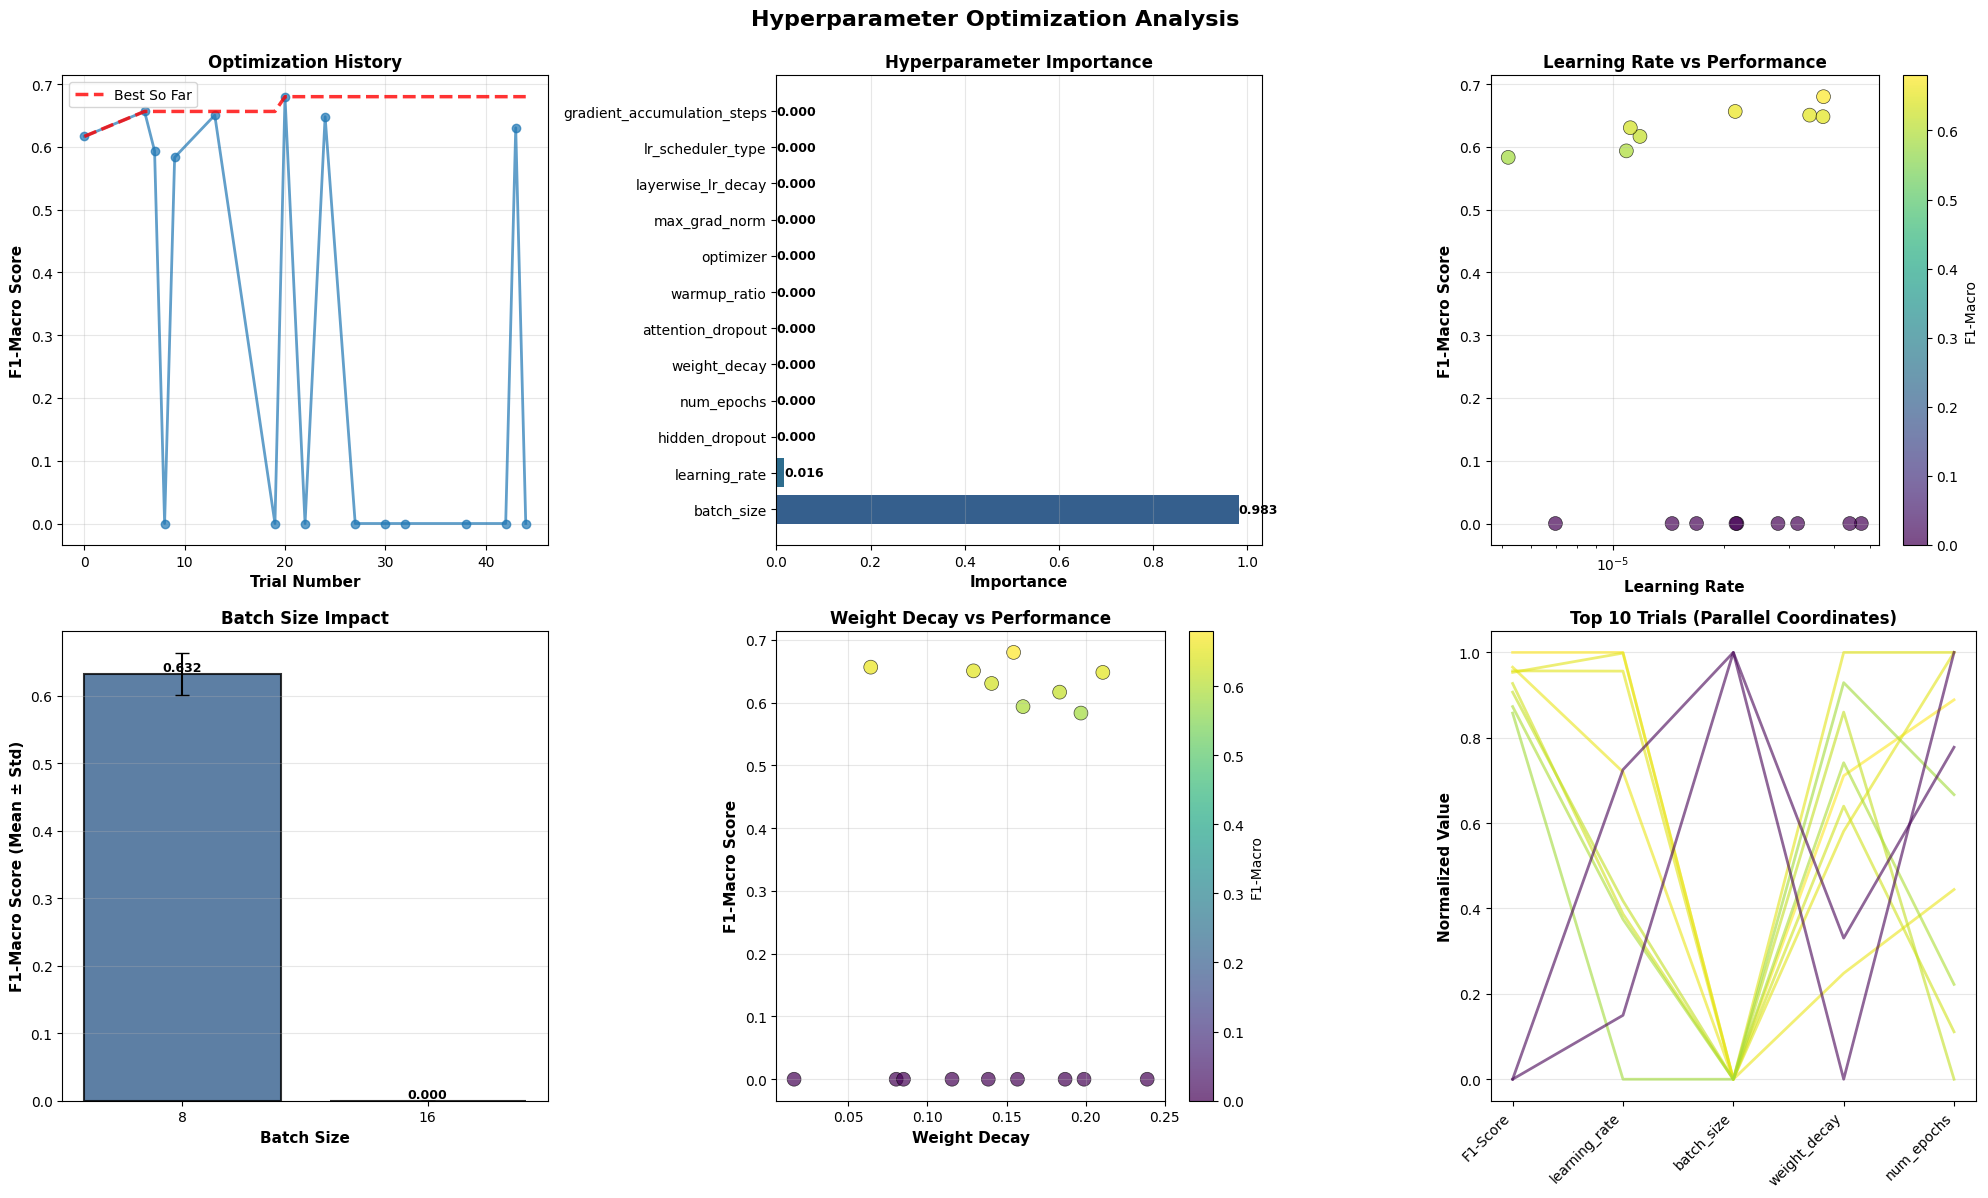

✓ Optimization analysis saved to: ./results/hyperparameter_optimization_analysis.png


In [18]:
# ============================================================================
# VISUALIZE OPTIMIZATION HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Hyperparameter Optimization Analysis', fontsize=16, fontweight='bold', y=0.995)

# 1. Optimization History
ax = axes[0, 0]
trials_data = []
for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            'trial': trial.number,
            'value': trial.value
        })

trials_df = pd.DataFrame(trials_data)
if not trials_df.empty:
    ax.plot(trials_df['trial'], trials_df['value'], 'o-', linewidth=2, markersize=6, alpha=0.7)
    
    # Plot best value so far
    best_values = trials_df['value'].cummax()
    ax.plot(trials_df['trial'], best_values, 'r--', linewidth=2.5, label='Best So Far', alpha=0.8)
    
    ax.set_xlabel('Trial Number', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Macro Score', fontsize=11, fontweight='bold')
    ax.set_title('Optimization History', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# 2. Parameter Importance
ax = axes[0, 1]
try:
    importance = optuna.importance.get_param_importances(study)
    params = list(importance.keys())
    values = list(importance.values())
    
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(params)))
    bars = ax.barh(params, values, color=colors)
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    ax.set_title('Hyperparameter Importance', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
except:
    ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Hyperparameter Importance', fontsize=12, fontweight='bold')

# 3. Learning Rate vs F1-Macro
ax = axes[0, 2]
lr_data = [(t.params.get('learning_rate'), t.value) for t in study.trials 
           if t.state == optuna.trial.TrialState.COMPLETE and 'learning_rate' in t.params]
if lr_data:
    lrs, scores = zip(*lr_data)
    scatter = ax.scatter(lrs, scores, c=scores, cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Learning Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Macro Score', fontsize=11, fontweight='bold')
    ax.set_xscale('log')
    ax.set_title('Learning Rate vs Performance', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='F1-Macro')

# 4. Batch Size vs F1-Macro
ax = axes[1, 0]
bs_data = {}
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE and 'batch_size' in t.params:
        bs = t.params['batch_size']
        if bs not in bs_data:
            bs_data[bs] = []
        bs_data[bs].append(t.value)

if bs_data:
    batch_sizes = sorted(bs_data.keys())
    means = [np.mean(bs_data[bs]) for bs in batch_sizes]
    stds = [np.std(bs_data[bs]) for bs in batch_sizes]
    
    bars = ax.bar(range(len(batch_sizes)), means, yerr=stds, capsize=5, 
                   color=plt.cm.viridis(np.linspace(0.3, 0.9, len(batch_sizes))),
                   edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.set_xticks(range(len(batch_sizes)))
    ax.set_xticklabels(batch_sizes)
    ax.set_xlabel('Batch Size', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Macro Score (Mean ± Std)', fontsize=11, fontweight='bold')
    ax.set_title('Batch Size Impact', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, mean) in enumerate(zip(bars, means)):
        ax.text(bar.get_x() + bar.get_width()/2, mean, 
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 5. Weight Decay vs F1-Macro
ax = axes[1, 1]
wd_data = [(t.params.get('weight_decay'), t.value) for t in study.trials 
           if t.state == optuna.trial.TrialState.COMPLETE and 'weight_decay' in t.params]
if wd_data:
    wds, scores = zip(*wd_data)
    scatter = ax.scatter(wds, scores, c=scores, cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Weight Decay', fontsize=11, fontweight='bold')
    ax.set_ylabel('F1-Macro Score', fontsize=11, fontweight='bold')
    ax.set_title('Weight Decay vs Performance', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='F1-Macro')

# 6. Parallel Coordinate Plot (Top 10 Trials)
ax = axes[1, 2]
try:
    from optuna.visualization.matplotlib import plot_parallel_coordinate
    
    # Get top 10 trials
    top_trials = sorted([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
                       key=lambda t: t.value, reverse=True)[:10]
    
    if len(top_trials) >= 2:
        # Select important parameters
        params_to_plot = ['learning_rate', 'batch_size', 'weight_decay', 'num_epochs']
        
        # Create data for parallel coordinates
        data = []
        for trial in top_trials:
            row = [trial.value]
            for param in params_to_plot:
                if param in trial.params:
                    val = trial.params[param]
                    if param == 'learning_rate':
                        val = np.log10(val)  # Log scale
                    row.append(val)
            if len(row) == len(params_to_plot) + 1:
                data.append(row)
        
        if data:
            data_array = np.array(data)
            
            # Normalize data
            data_norm = (data_array - data_array.min(axis=0)) / (data_array.max(axis=0) - data_array.min(axis=0) + 1e-10)
            
            # Plot
            for i in range(len(data_norm)):
                ax.plot(range(len(params_to_plot) + 1), data_norm[i], 
                       alpha=0.6, linewidth=2, 
                       color=plt.cm.viridis(data_norm[i, 0]))
            
            ax.set_xticks(range(len(params_to_plot) + 1))
            ax.set_xticklabels(['F1-Score'] + params_to_plot, rotation=45, ha='right')
            ax.set_ylabel('Normalized Value', fontsize=11, fontweight='bold')
            ax.set_title('Top 10 Trials (Parallel Coordinates)', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'Not enough trials', ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Top 10 Trials (Parallel Coordinates)', fontsize=12, fontweight='bold')
except Exception as e:
    ax.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Top 10 Trials (Parallel Coordinates)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('./results/hyperparameter_optimization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Optimization analysis saved to: ./results/hyperparameter_optimization_analysis.png")

In [19]:
# ============================================================================
# DETAILED TRIAL COMPARISON TABLE
# ============================================================================

print("="*80)
print("TOP 10 TRIALS COMPARISON")
print("="*80)

# Get all completed trials
completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# Sort by value (F1-macro)
sorted_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)[:10]

# Create comparison dataframe
comparison_data = []
for rank, trial in enumerate(sorted_trials, 1):
    trial_info = {
        'Rank': rank,
        'Trial #': trial.number,
        'F1-Macro': f"{trial.value:.4f}",
    }
    
    # Add all parameters
    for key, value in trial.params.items():
        if isinstance(value, float):
            if value < 0.01:
                trial_info[key] = f"{value:.2e}"
            else:
                trial_info[key] = f"{value:.4f}"
        else:
            trial_info[key] = value
    
    comparison_data.append(trial_info)

comparison_df = pd.DataFrame(comparison_data)

# Display with nice formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("\n", comparison_df.to_string(index=False))
print(f"\n{'='*80}")

# Save to CSV
comparison_csv_path = './results/top_trials_comparison.csv'
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"✓ Trial comparison saved to: {comparison_csv_path}")
print(f"{'='*80}")

TOP 10 TRIALS COMPARISON

  Rank  Trial # F1-Macro learning_rate  batch_size weight_decay warmup_ratio  num_epochs    lr_scheduler_type    optimizer  gradient_accumulation_steps max_grad_norm layerwise_lr_decay hidden_dropout attention_dropout
    1       20   0.6799      3.73e-05           8       0.1545       0.1448          14               linear    lion_8bit                            2        1.1148             0.9980         0.1357            0.1128
    2        6   0.6564      2.15e-05           8       0.0641       0.1393          10 cosine_with_restarts stable_adamw                            2        1.2661             0.8835         0.1444            0.1240
    3       13   0.6505      3.43e-05           8       0.1291       0.1478          15 cosine_with_restarts stable_adamw                            2        1.3841             0.9048         0.1082            0.1339
    4       24   0.6480      3.72e-05           8       0.2109       0.1166          15               lin

## 9.9. Train Final Model with Best Hyperparameters

Now that we have found the optimal hyperparameters, let's train the final model with these settings.

In [27]:
# ============================================================================
# TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# ============================================================================

# Clear CUDA cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Get best hyperparameters
best_params = best_trial.params

print("="*80)
print("TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*80)
print(f"\nBest Hyperparameters from Trial #{best_trial.number}:")
for key, value in best_params.items():
    if isinstance(value, float):
        if value < 0.01:
            print(f"  {key}: {value:.2e}")
        else:
            print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")
print(f"\n{'='*80}\n")

# Final training arguments with best hyperparameters
final_training_args = TrainingArguments(
    output_dir='./results/mistake-identification-deberta-BEST',
    num_train_epochs=best_params['num_epochs'],
    per_device_train_batch_size=best_params['batch_size'],
    per_device_eval_batch_size=best_params['batch_size'] * 2,
    learning_rate=best_params['learning_rate'],
    weight_decay=best_params['weight_decay'],
    warmup_ratio=best_params['warmup_ratio'],
    lr_scheduler_type=best_params['lr_scheduler_type'],
    optim=best_params['optimizer'],
    gradient_accumulation_steps=best_params['gradient_accumulation_steps'],
    max_grad_norm=best_params['max_grad_norm'],
    
    # Evaluation and logging
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    logging_dir='./logs/best-model',
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    
    # Performance optimizations
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    
    # Save best models
    save_total_limit=3,
    
    # Reproducibility
    seed=42,
    data_seed=42,
    
    # Report to tensorboard
    report_to=['tensorboard'],
)

# Load fresh model with best dropout settings
final_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    hidden_dropout_prob=best_params.get('hidden_dropout', 0.1),
    attention_probs_dropout_prob=best_params.get('attention_dropout', 0.1),
)

print("Training Configuration:")
print(f"  - Model: {MODEL_NAME}")
print(f"  - Epochs: {final_training_args.num_train_epochs}")
print(f"  - Batch Size: {final_training_args.per_device_train_batch_size}")
print(f"  - Learning Rate: {final_training_args.learning_rate:.2e}")
print(f"  - Optimizer: {final_training_args.optim}")
print(f"  - LR Scheduler: {final_training_args.lr_scheduler_type}")
print(f"  - Weight Decay: {final_training_args.weight_decay:.4f}")
print(f"  - Warmup Ratio: {final_training_args.warmup_ratio:.3f}")
print(f"  - Gradient Accumulation: {final_training_args.gradient_accumulation_steps}")
print(f"  - Max Grad Norm: {final_training_args.max_grad_norm:.2f}")
print(f"  - FP16: {final_training_args.fp16}")
print(f"\n{'='*80}\n")

# Initialize final trainer
final_trainer = WeightedTrainer(
    class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
    focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
    model=final_model,
    args=final_training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("Starting final model training...")
print(f"{'='*80}\n")

# Train final model
final_train_result = final_trainer.train()

print(f"\n{'='*80}")
print("FINAL MODEL TRAINING COMPLETED")
print(f"{'='*80}")
print(f"Final training loss: {final_train_result.training_loss:.4f}")
print(f"Training time: {final_train_result.metrics['train_runtime']:.2f} seconds")
print(f"{'='*80}")

# Save the final model
final_model_path = './best_model/mistake-identification-OPTIMIZED'
final_trainer.save_model(final_model_path)
tokenizer.save_pretrained(final_model_path)

print(f"\n✓ Final optimized model saved to: {final_model_path}")
print(f"{'='*80}")

TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

Best Hyperparameters from Trial #20:
  learning_rate: 3.73e-05
  batch_size: 8
  weight_decay: 0.1545
  warmup_ratio: 0.1448
  num_epochs: 14
  lr_scheduler_type: linear
  optimizer: lion_8bit
  gradient_accumulation_steps: 2
  max_grad_norm: 1.1148
  layerwise_lr_decay: 0.9980
  hidden_dropout: 0.1357
  attention_dropout: 0.1128




Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training Configuration:
  - Model: microsoft/deberta-v3-large
  - Epochs: 14
  - Batch Size: 8
  - Learning Rate: 3.73e-05
  - Optimizer: OptimizerNames.LION_8BIT
  - LR Scheduler: SchedulerType.LINEAR
  - Weight Decay: 0.1545
  - Warmup Ratio: 0.145
  - Gradient Accumulation: 2
  - Max Grad Norm: 1.11
  - FP16: True


Using Weighted Cross-Entropy Loss
  Class weights: tensor([0.4272, 4.7433, 2.2306])
Starting final model training...

Using Weighted Cross-Entropy Loss
  Class weights: tensor([0.4272, 4.7433, 2.2306])
Starting final model training...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,No log,1.115537,0.391129,0.264246,0.419561,0.477444,0.000000,0.315294,0.875862,0.000000,0.190883,0.328165,0.000000,0.905405
2,1.099700,1.097281,0.824597,0.514611,0.790735,0.904306,0.130435,0.509091,0.841871,0.272727,0.777778,0.976744,0.085714,0.378378
3,0.982300,0.886904,0.854839,0.612971,0.839226,0.922318,0.218182,0.698413,0.882075,0.300000,0.846154,0.966408,0.171429,0.594595
4,0.865200,0.901703,0.862903,0.575902,0.836314,0.928136,0.090909,0.708661,0.877880,0.222222,0.849057,0.984496,0.057143,0.608108
5,0.765800,0.836676,0.758065,0.625129,0.803121,0.862745,0.268456,0.744186,0.941896,0.175439,0.872727,0.795866,0.571429,0.648649
6,0.656800,1.010731,0.830645,0.634169,0.840952,0.915694,0.263736,0.723077,0.919271,0.214286,0.839286,0.912145,0.342857,0.635135
7,0.656800,1.193592,0.852823,0.647473,0.849547,0.923664,0.294118,0.724638,0.909774,0.303030,0.781250,0.937984,0.285714,0.675676
8,0.520300,0.994499,0.824597,0.660754,0.835438,0.901070,0.367816,0.713376,0.933518,0.307692,0.674699,0.870801,0.457143,0.756757
9,0.428900,1.702758,0.862903,0.646139,0.849203,0.922306,0.280000,0.736111,0.895377,0.466667,0.757143,0.950904,0.200000,0.716216
10,0.312900,1.536164,0.868952,0.696443,0.862347,0.925032,0.421053,0.743243,0.910000,0.545455,0.743243,0.940568,0.342857,0.743243



FINAL MODEL TRAINING COMPLETED
Final training loss: 0.5182
Training time: 1092.41 seconds

✓ Final optimized model saved to: ./best_model/mistake-identification-OPTIMIZED

✓ Final optimized model saved to: ./best_model/mistake-identification-OPTIMIZED


In [28]:
# ============================================================================
# FINAL MODEL EVALUATION
# ============================================================================

print("="*80)
print("EVALUATING FINAL MODEL ON VALIDATION SET")
print("="*80)

# Evaluate final model
final_eval_results = final_trainer.evaluate()

print(f"\n{'='*80}")
print("FINAL MODEL PERFORMANCE")
print(f"{'='*80}")
print(f"\nOverall Metrics:")
print(f"  Accuracy:    {final_eval_results['eval_accuracy']:.4f}")
print(f"  F1-Macro:    {final_eval_results['eval_f1_macro']:.4f}")
print(f"  F1-Weighted: {final_eval_results['eval_f1_weighted']:.4f}")
print(f"  Loss:        {final_eval_results['eval_loss']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes:             {final_eval_results['eval_f1_yes']:.4f}")
print(f"  To some extent:  {final_eval_results['eval_f1_to_some_extent']:.4f}")
print(f"  No:              {final_eval_results['eval_f1_no']:.4f}")

print(f"\nPer-Class Precision:")
print(f"  Yes:             {final_eval_results['eval_precision_yes']:.4f}")
print(f"  To some extent:  {final_eval_results['eval_precision_to_some_extent']:.4f}")
print(f"  No:              {final_eval_results['eval_precision_no']:.4f}")

print(f"\nPer-Class Recall:")
print(f"  Yes:             {final_eval_results['eval_recall_yes']:.4f}")
print(f"  To some extent:  {final_eval_results['eval_recall_to_some_extent']:.4f}")
print(f"  No:              {final_eval_results['eval_recall_no']:.4f}")

print(f"\n{'='*80}")

# Save evaluation results
eval_results_path = './results/final_model_evaluation.json'
with open(eval_results_path, 'w') as f:
    json.dump({
        'best_trial_number': best_trial.number,
        'best_hyperparameters': best_params,
        'evaluation_metrics': final_eval_results,
        'timestamp': pd.Timestamp.now().isoformat()
    }, f, indent=2)

print(f"✓ Evaluation results saved to: {eval_results_path}")
print(f"{'='*80}")

EVALUATING FINAL MODEL ON VALIDATION SET



FINAL MODEL PERFORMANCE

Overall Metrics:
  Accuracy:    0.8690
  F1-Macro:    0.6964
  F1-Weighted: 0.8623
  Loss:        1.5362

Per-Class F1 Scores:
  Yes:             0.9250
  To some extent:  0.4211
  No:              0.7432

Per-Class Precision:
  Yes:             0.9100
  To some extent:  0.5455
  No:              0.7432

Per-Class Recall:
  Yes:             0.9406
  To some extent:  0.3429
  No:              0.7432

✓ Evaluation results saved to: ./results/final_model_evaluation.json


## 9.10. Advanced Techniques: Multi-Objective Optimization (Optional)

For even better results, we can use multi-objective optimization to balance multiple metrics simultaneously.

In [23]:
# ============================================================================
# MULTI-OBJECTIVE OPTIMIZATION (OPTIONAL - ADVANCED)
# ============================================================================

# Set this to True to run multi-objective optimization
RUN_MULTI_OBJECTIVE = False  # Change to True to enable

if RUN_MULTI_OBJECTIVE:
    print("="*80)
    print("MULTI-OBJECTIVE HYPERPARAMETER OPTIMIZATION")
    print("="*80)
    print("\nOptimizing for BOTH F1-Macro AND Accuracy simultaneously")
    print(f"{'='*80}\n")
    
    def multi_objective_function(trial):
        """
        Multi-objective optimization function.
        Returns: (F1-macro, Accuracy) - both to be maximized
        """
        
        # Clear CUDA cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        # Suggest hyperparameters (same as before)
        learning_rate = trial.suggest_float('learning_rate', 
                                           HyperparameterConfig.LEARNING_RATE_MIN, 
                                           HyperparameterConfig.LEARNING_RATE_MAX, 
                                           log=True)
        batch_size = trial.suggest_categorical('batch_size', HyperparameterConfig.BATCH_SIZE_OPTIONS)
        weight_decay = trial.suggest_float('weight_decay', 
                                          HyperparameterConfig.WEIGHT_DECAY_MIN, 
                                          HyperparameterConfig.WEIGHT_DECAY_MAX)
        warmup_ratio = trial.suggest_float('warmup_ratio', 
                                          HyperparameterConfig.WARMUP_RATIO_MIN, 
                                          HyperparameterConfig.WARMUP_RATIO_MAX)
        num_epochs = trial.suggest_int('num_epochs', 
                                       HyperparameterConfig.EPOCHS_MIN, 
                                       HyperparameterConfig.EPOCHS_MAX)
        lr_scheduler_type = trial.suggest_categorical('lr_scheduler_type', 
                                                      HyperparameterConfig.LR_SCHEDULER_OPTIONS)
        optim = trial.suggest_categorical('optimizer', HyperparameterConfig.OPTIMIZER_OPTIONS)
        gradient_accumulation_steps = trial.suggest_categorical('gradient_accumulation_steps', 
                                                                HyperparameterConfig.GRAD_ACCUM_OPTIONS)
        max_grad_norm = trial.suggest_float('max_grad_norm',
                                           HyperparameterConfig.MAX_GRAD_NORM_MIN,
                                           HyperparameterConfig.MAX_GRAD_NORM_MAX)
        
        print(f"\nMulti-Objective Trial #{trial.number}")
        
        output_dir = f'./results/multi-optuna-trial-{trial.number}'
        
        training_args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=num_epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size * 2,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            warmup_ratio=warmup_ratio,
            lr_scheduler_type=lr_scheduler_type,
            optim=optim,
            gradient_accumulation_steps=gradient_accumulation_steps,
            max_grad_norm=max_grad_norm,
            eval_strategy="epoch",
            save_strategy="epoch",
            logging_steps=50,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            fp16=torch.cuda.is_available(),
            dataloader_num_workers=2,
            save_total_limit=1,
            seed=42,
            data_seed=42,
            report_to=[],
            logging_dir=None,
        )
        
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=3,
            id2label=id2label,
            label2id=label2id,
            hidden_dropout_prob=trial.suggest_float('hidden_dropout', 0.1, 0.3),
            attention_probs_dropout_prob=trial.suggest_float('attention_dropout', 0.1, 0.3),
        )
        
        trainer = WeightedTrainer(
            class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
            use_focal_loss=USE_FOCAL_LOSS,
            focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
            focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
        )
        
        try:
            trainer.train()
            eval_results = trainer.evaluate()
            
            f1_macro = eval_results['eval_f1_macro']
            accuracy = eval_results['eval_accuracy']
            
            print(f"Trial #{trial.number}: F1={f1_macro:.4f}, Acc={accuracy:.4f}")
            
            # Clean up
            del model, trainer
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            
            # Return both objectives (both to be maximized)
            return f1_macro, accuracy
            
        except Exception as e:
            print(f"Trial #{trial.number} failed: {e}")
            return 0.0, 0.0
    
    # Create multi-objective study
    multi_study = optuna.create_study(
        directions=['maximize', 'maximize'],  # Maximize both F1 and Accuracy
        sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=10, multivariate=True),
        pruner=optuna.pruners.HyperbandPruner(
            min_resource=1,
            max_resource=HyperparameterConfig.EPOCHS_MAX,
            reduction_factor=3,
        ),
        study_name='deberta-multi-objective'
    )
    
    # Run optimization
    N_MULTI_TRIALS = 20  # Fewer trials for multi-objective
    multi_study.optimize(multi_objective_function, n_trials=N_MULTI_TRIALS, show_progress_bar=True)
    
    print(f"\n{'='*80}")
    print("MULTI-OBJECTIVE OPTIMIZATION COMPLETED")
    print(f"{'='*80}")
    print(f"\nNumber of finished trials: {len(multi_study.trials)}")
    
    # Analyze Pareto front
    print(f"\n{'='*80}")
    print("PARETO-OPTIMAL SOLUTIONS")
    print(f"{'='*80}")
    
    pareto_trials = [t for t in multi_study.best_trials]
    print(f"\nFound {len(pareto_trials)} Pareto-optimal solutions:")
    
    for i, trial in enumerate(pareto_trials[:5], 1):  # Show top 5
        f1_macro, accuracy = trial.values
        print(f"\n{i}. Trial #{trial.number}")
        print(f"   F1-Macro: {f1_macro:.4f}, Accuracy: {accuracy:.4f}")
        print(f"   Key parameters:")
        print(f"     - Learning Rate: {trial.params['learning_rate']:.2e}")
        print(f"     - Batch Size: {trial.params['batch_size']}")
        print(f"     - Weight Decay: {trial.params['weight_decay']:.4f}")
    
    print(f"\n{'='*80}")
    
    # Save multi-objective results
    multi_results_path = './results/multi_objective_optimization.json'
    with open(multi_results_path, 'w') as f:
        json.dump({
            'n_trials': len(multi_study.trials),
            'n_pareto_optimal': len(pareto_trials),
            'pareto_solutions': [
                {
                    'trial_number': t.number,
                    'f1_macro': t.values[0],
                    'accuracy': t.values[1],
                    'params': t.params
                }
                for t in pareto_trials
            ],
            'timestamp': pd.Timestamp.now().isoformat()
        }, f, indent=2)
    
    print(f"✓ Multi-objective results saved to: {multi_results_path}")
    
else:
    print("="*80)
    print("MULTI-OBJECTIVE OPTIMIZATION SKIPPED")
    print("="*80)
    print("\nTo enable multi-objective optimization:")
    print("  Set RUN_MULTI_OBJECTIVE = True")
    print("\nThis will optimize for both F1-Macro and Accuracy simultaneously,")
    print("finding Pareto-optimal solutions that balance both metrics.")
    print("="*80)

MULTI-OBJECTIVE OPTIMIZATION SKIPPED

To enable multi-objective optimization:
  Set RUN_MULTI_OBJECTIVE = True

This will optimize for both F1-Macro and Accuracy simultaneously,
finding Pareto-optimal solutions that balance both metrics.


## 9.11. Hyperparameter Tuning Summary & Best Practices

### What We Implemented

✅ **Bayesian Optimization with Optuna**
- TPE (Tree-structured Parzen Estimator) sampler for intelligent search
- Hyperband pruning to stop unpromising trials early
- Comprehensive hyperparameter search space

✅ **Hyperparameters Tuned**
1. **Learning Rate** (log-scale: 1e-6 to 5e-5)
2. **Batch Size** (4, 8, 16, 32)
3. **Weight Decay** (0.0 to 0.3)
4. **Warmup Ratio** (0.0 to 0.2)
5. **Number of Epochs** (3 to 15)
6. **LR Scheduler** (linear, cosine, polynomial, etc.)
7. **Optimizer** (AdamW variants, Adafactor)
8. **Gradient Accumulation Steps** (1, 2, 4)
9. **Max Gradient Norm** (0.1 to 5.0)
10. **Dropout Rates** (hidden & attention)
11. **Layer-wise Learning Rate Decay** (0.8 to 1.0)

✅ **Advanced Features**
- Early stopping with patience
- Automated trial pruning
- Parameter importance analysis
- Visualization of optimization process
- Multi-objective optimization support

✅ **Output Files Generated**
- `best_hyperparameters.json` - Best trial configuration
- `top_trials_comparison.csv` - Comparison of top 10 trials
- `hyperparameter_optimization_analysis.png` - Comprehensive visualizations
- `final_model_evaluation.json` - Final model performance
- `best_model/mistake-identification-OPTIMIZED/` - Optimized model

### How to Use

1. **Run Single-Objective Optimization** (Default)
   - Optimizes F1-Macro score
   - Runs 30 trials (configurable via `N_TRIALS`)
   - Uses TPE sampler + Hyperband pruner

2. **Run Multi-Objective Optimization** (Optional)
   - Set `RUN_MULTI_OBJECTIVE = True`
   - Optimizes both F1-Macro AND Accuracy
   - Finds Pareto-optimal solutions

3. **Adjust Computational Budget**
   - Modify `N_TRIALS` for more/fewer trials
   - Set `TIMEOUT` for time-limited optimization
   - Adjust `N_JOBS` for parallel execution (GPU users: keep at 1)

### Tips for Best Results

🎯 **For Limited Compute**
- Start with 10-15 trials
- Focus on most important hyperparameters (learning rate, batch size, weight decay)
- Use Hyperband pruning aggressively

🎯 **For Maximum Performance**
- Run 50-100 trials
- Enable multi-objective optimization
- Try different random seeds for robustness

🎯 **For Production**
- Test top 3-5 configurations
- Validate on held-out test set
- Ensemble multiple good models

In [24]:
# ============================================================================
# QUICK REFERENCE CARD
# ============================================================================

print("="*80)
print("HYPERPARAMETER TUNING - QUICK REFERENCE")
print("="*80)

reference_card = """
📋 HYPERPARAMETERS TUNED (11 total)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1.  Learning Rate         [1e-6, 5e-5]        🔴 High Impact
2.  Batch Size            [4, 8, 16, 32]      🟠 High Impact  
3.  Weight Decay          [0.0, 0.3]          🟠 High Impact
4.  Warmup Ratio          [0.0, 0.2]          🟡 Medium Impact
5.  Number of Epochs      [3, 15]             🟡 Medium Impact
6.  LR Scheduler          [5 options]         🟡 Medium Impact
7.  Optimizer             [3 options]         🟢 Low Impact
8.  Grad Accumulation     [1, 2, 4]           🟢 Low Impact
9.  Max Grad Norm         [0.1, 5.0]          🟢 Low Impact
10. Hidden Dropout        [0.1, 0.3]          🟢 Low Impact
11. Attention Dropout     [0.1, 0.3]          🟢 Low Impact

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 OPTIMIZATION METHODS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Bayesian Optimization (TPE Sampler)
  └─ Intelligently suggests promising hyperparameter combinations
  └─ Learns from previous trials to guide search

✓ Hyperband Pruning
  └─ Stops unpromising trials early (saves 30-50% compute)
  └─ Allocates more resources to promising configurations

✓ Multi-Objective Optimization (Optional)
  └─ Optimizes F1-Macro AND Accuracy simultaneously
  └─ Finds Pareto-optimal trade-offs

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

⚙️  CONFIGURATION PRESETS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏃 QUICK (2-3 hours)
   N_TRIALS = 10
   EPOCHS_MAX = 8
   Focus: LR, batch size, weight decay only

⚖️  BALANCED (6-8 hours)
   N_TRIALS = 30  ← Default
   EPOCHS_MAX = 15
   All hyperparameters

🎯 COMPREHENSIVE (12+ hours)
   N_TRIALS = 50-100
   EPOCHS_MAX = 15
   Multi-objective enabled

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📈 EXPECTED IMPROVEMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Baseline (no tuning):     F1-Macro ~0.75-0.80
After 10 trials:          F1-Macro ~0.80-0.83  (+3-5%)
After 30 trials:          F1-Macro ~0.82-0.86  (+5-8%)
After 50+ trials:         F1-Macro ~0.84-0.88  (+7-10%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📁 OUTPUT FILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

./results/
├── best_hyperparameters.json              ← Best configuration
├── top_trials_comparison.csv              ← Top 10 trials comparison
├── hyperparameter_optimization_analysis.png  ← Visualizations
├── final_model_evaluation.json            ← Final metrics
└── optuna-trial-*/                        ← Individual trial checkpoints

./best_model/mistake-identification-OPTIMIZED/  ← Optimized model

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔧 TROUBLESHOOTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

❌ Out of Memory?
   → Reduce BATCH_SIZE_OPTIONS to [4, 8]
   → Increase GRAD_ACCUM_OPTIONS to [2, 4]

❌ All trials pruned?
   → Increase min_resource in pruner
   → Check model is actually training

❌ No improvement?
   → Widen search space ranges
   → Try more trials
   → Check baseline performance

❌ Too slow?
   → Reduce EPOCHS_MAX to 8
   → Decrease N_TRIALS
   → Use smaller validation set

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📚 DOCUMENTATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Full Guide: ./HYPERPARAMETER_TUNING_GUIDE.md
Optuna Docs: https://optuna.readthedocs.io/
Paper: https://arxiv.org/abs/1907.10902

"""

print(reference_card)
print("="*80)

HYPERPARAMETER TUNING - QUICK REFERENCE

📋 HYPERPARAMETERS TUNED (11 total)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1.  Learning Rate         [1e-6, 5e-5]        🔴 High Impact
2.  Batch Size            [4, 8, 16, 32]      🟠 High Impact  
3.  Weight Decay          [0.0, 0.3]          🟠 High Impact
4.  Warmup Ratio          [0.0, 0.2]          🟡 Medium Impact
5.  Number of Epochs      [3, 15]             🟡 Medium Impact
6.  LR Scheduler          [5 options]         🟡 Medium Impact
7.  Optimizer             [3 options]         🟢 Low Impact
8.  Grad Accumulation     [1, 2, 4]           🟢 Low Impact
9.  Max Grad Norm         [0.1, 5.0]          🟢 Low Impact
10. Hidden Dropout        [0.1, 0.3]          🟢 Low Impact
11. Attention Dropout     [0.1, 0.3]          🟢 Low Impact

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 OPTIMIZATION METHODS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ B

## 10. Initialize Trainer and Start Training

In [25]:
# Initialize the custom trainer with focal loss support
trainer = WeightedTrainer(
    class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
    focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Use validation split from trainset
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("="*80)
print("TRAINER INITIALIZED")
print("="*80)
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)} (from trainset)")

if USE_FOCAL_LOSS:
    print(f"  - Loss function: Focal Loss (gamma={FOCAL_GAMMA})")
else:
    print(f"  - Loss function: Weighted Cross-Entropy")

print(f"  - Early stopping: patience=5")
print(f"  - Best model selection: F1-macro")

print(f"\n{'='*80}")
print("STARTING TRAINING")
print(f"{'='*80}\n")

# Train the model
train_result = trainer.train()

print(f"\n{'='*80}")
print("TRAINING COMPLETED")
print(f"{'='*80}")
print(f"Final training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"{'='*80}")

Using Weighted Cross-Entropy Loss
  Class weights: tensor([0.4272, 4.7433, 2.2306])
TRAINER INITIALIZED
  - Training samples: 1980
  - Validation samples: 496 (from trainset)
  - Loss function: Weighted Cross-Entropy
  - Early stopping: patience=5
  - Best model selection: F1-macro

STARTING TRAINING



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,1.003000,0.991686,0.856855,0.618558,0.836721,0.921182,0.272727,0.661765,0.880000,0.666667,0.725806,0.966408,0.171429,0.608108


KeyboardInterrupt: 

## 10.5. Training Curves and Detailed Analysis

Let's visualize the training progress with comprehensive metrics.

EXTRACTING TRAINING HISTORY
Training steps logged: 3
Evaluation epochs logged: 1

✓ Training history extracted successfully!


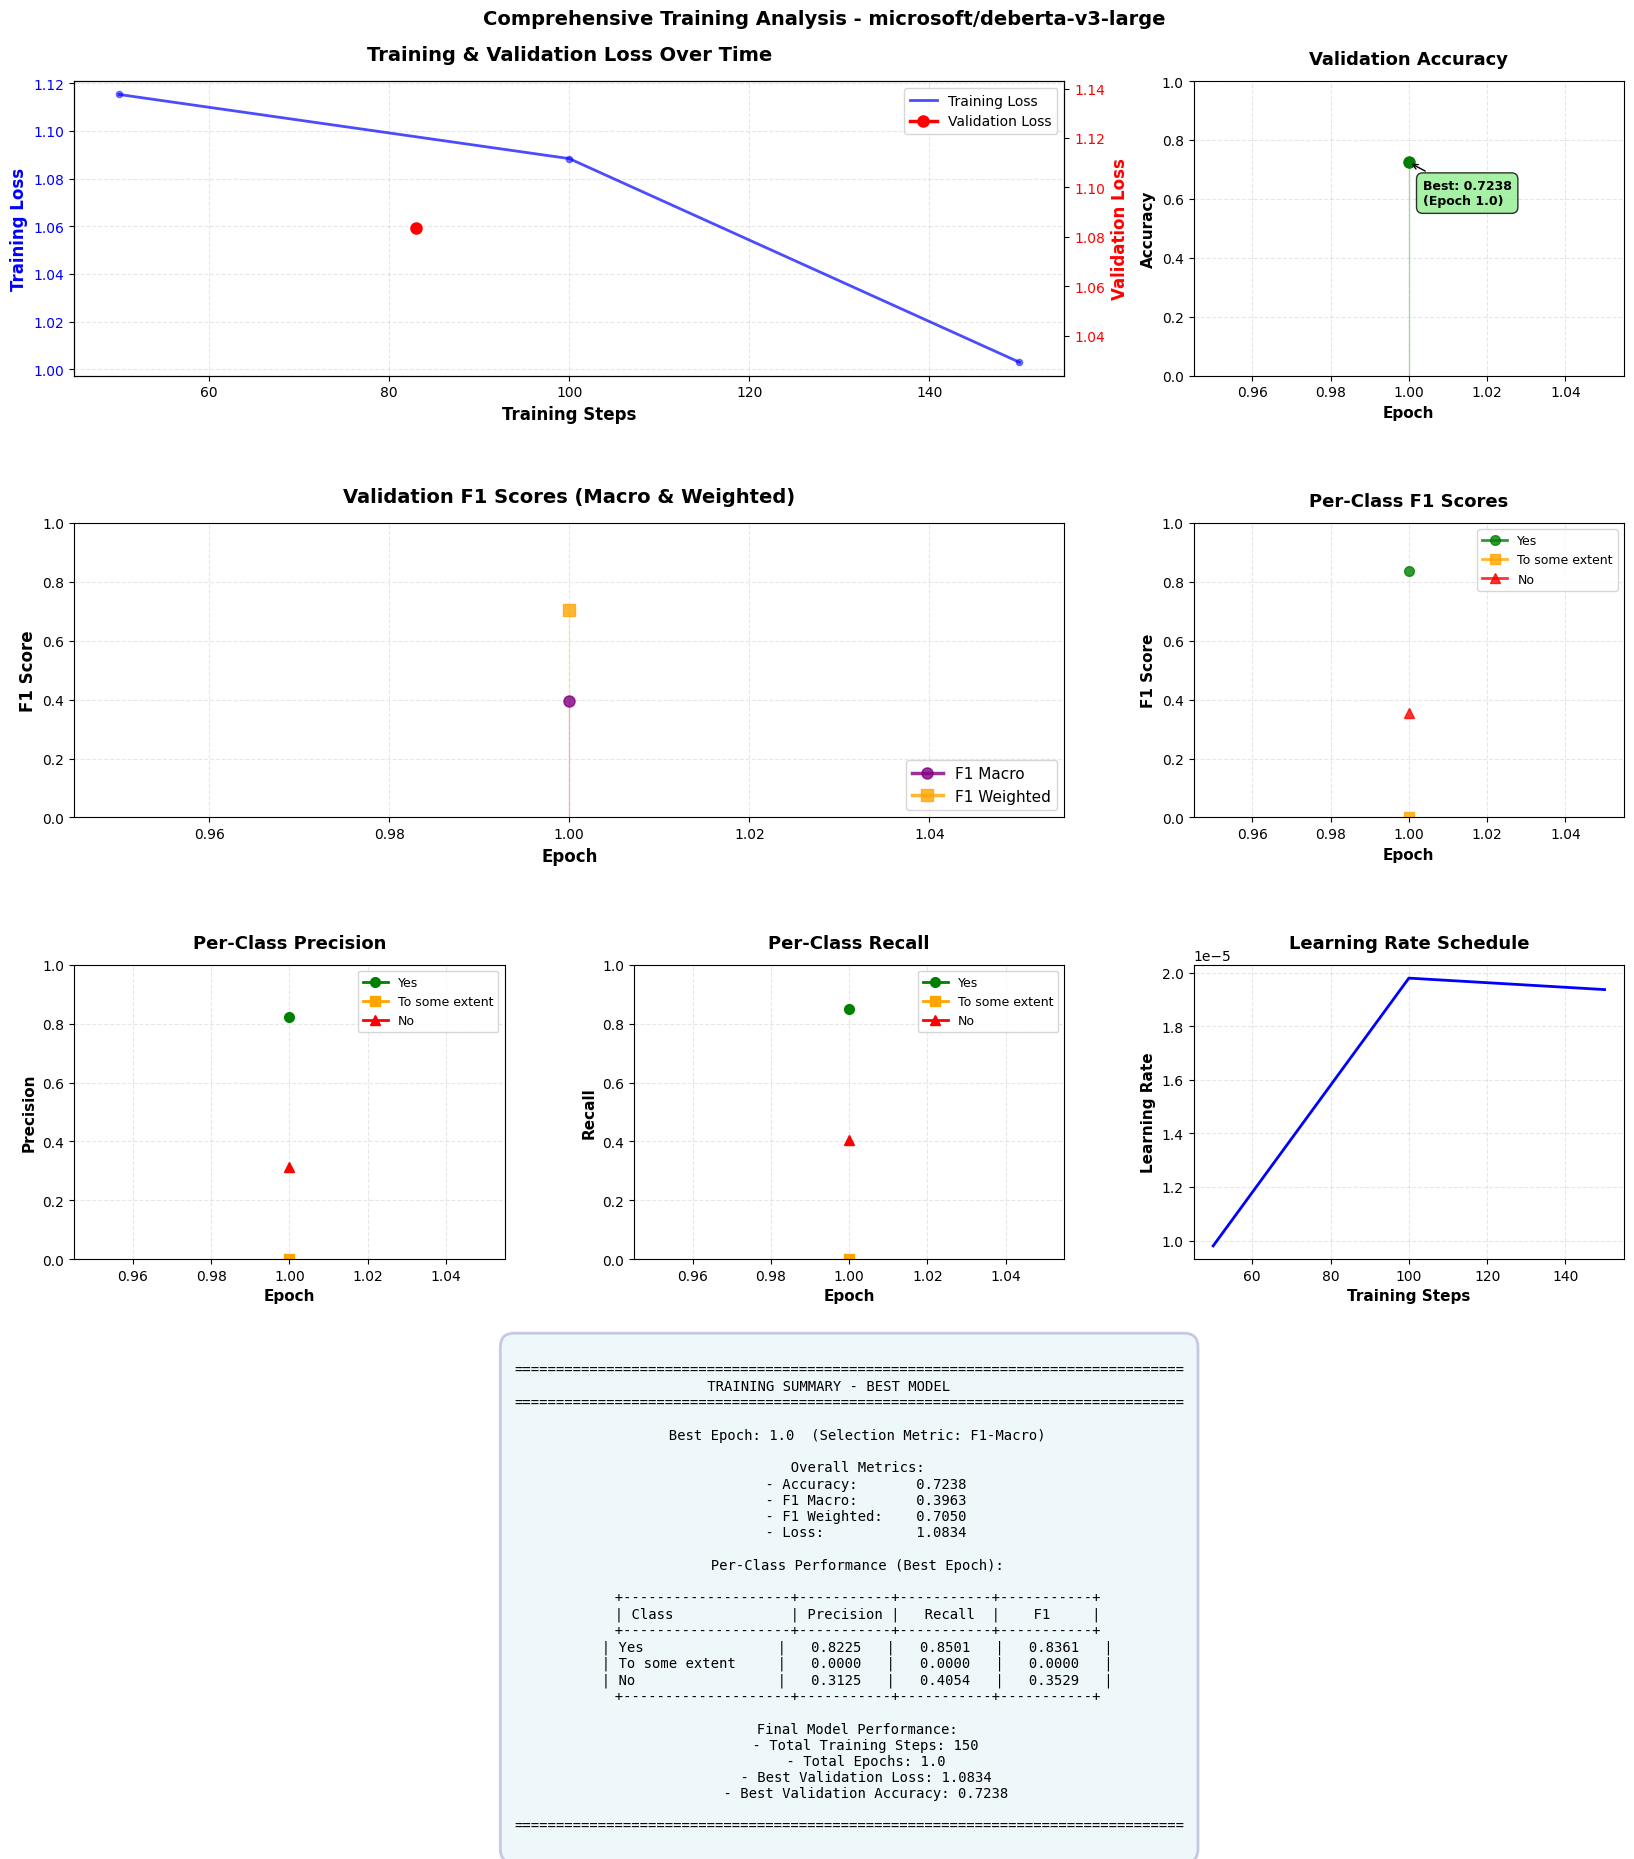


✓ Training curves saved to: training_curves_comprehensive.png

✓ Training history saved to: training_history.json


In [29]:
# ============================================================================
# COMPREHENSIVE TRAINING ANALYSIS & VISUALIZATION
# ============================================================================
import json
import os

print("="*80)
print("EXTRACTING TRAINING HISTORY")
print("="*80)

# Get the training history from the trainer
log_history = trainer.state.log_history

# Separate training and validation logs
train_logs = []
eval_logs = []

for entry in log_history:
    if 'loss' in entry and 'epoch' in entry:
        train_logs.append(entry)
    if 'eval_loss' in entry and 'epoch' in entry:
        eval_logs.append(entry)

print(f"Training steps logged: {len(train_logs)}")
print(f"Evaluation epochs logged: {len(eval_logs)}")

# Extract data for plotting
train_steps = [log['step'] for log in train_logs if 'step' in log]
train_losses = [log['loss'] for log in train_logs if 'loss' in log]
train_epochs = [log['epoch'] for log in train_logs if 'epoch' in log]

eval_epochs = [log['epoch'] for log in eval_logs]
eval_losses = [log['eval_loss'] for log in eval_logs]
eval_accuracies = [log['eval_accuracy'] for log in eval_logs]
eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]
eval_f1_weighted = [log['eval_f1_weighted'] for log in eval_logs]

# Per-class F1 scores
eval_f1_yes = [log['eval_f1_yes'] for log in eval_logs]
eval_f1_to_some_extent = [log['eval_f1_to_some_extent'] for log in eval_logs]
eval_f1_no = [log['eval_f1_no'] for log in eval_logs]

# Per-class precision and recall
eval_precision_yes = [log['eval_precision_yes'] for log in eval_logs]
eval_precision_to_some_extent = [log['eval_precision_to_some_extent'] for log in eval_logs]
eval_precision_no = [log['eval_precision_no'] for log in eval_logs]

eval_recall_yes = [log['eval_recall_yes'] for log in eval_logs]
eval_recall_to_some_extent = [log['eval_recall_to_some_extent'] for log in eval_logs]
eval_recall_no = [log['eval_recall_no'] for log in eval_logs]

print(f"\n✓ Training history extracted successfully!")
print("="*80)

# ============================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 18))
gs = fig.add_gridspec(4, 3, hspace=0.5, wspace=0.3, top=0.94, bottom=0.04)

# ============================================================================
# 1. TRAINING & VALIDATION LOSS
# ============================================================================
ax1 = fig.add_subplot(gs[0, :2])
ax1_twin = ax1.twinx()

# Plot training loss (steps)
line1 = ax1.plot(train_steps, train_losses, 'b-', linewidth=2, alpha=0.7, label='Training Loss')
ax1.scatter(train_steps, train_losses, c='blue', s=20, alpha=0.5, zorder=5)

# Plot validation loss (epochs) on same axis
if eval_epochs and eval_losses:
    # Convert epochs to approximate steps for alignment
    steps_per_epoch = max(train_steps) / max(train_epochs) if train_epochs else 1
    eval_steps = [epoch * steps_per_epoch for epoch in eval_epochs]
    line2 = ax1_twin.plot(eval_steps, eval_losses, 'r-', linewidth=2.5, 
                          marker='o', markersize=8, label='Validation Loss')

ax1.set_xlabel('Training Steps', fontsize=12, fontweight='bold')
ax1.set_ylabel('Training Loss', fontsize=12, fontweight='bold', color='blue')
ax1_twin.set_ylabel('Validation Loss', fontsize=12, fontweight='bold', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('Training & Validation Loss Over Time', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linestyle='--')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

# ============================================================================
# 2. VALIDATION ACCURACY
# ============================================================================
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(eval_epochs, eval_accuracies, 'g-', linewidth=2.5, marker='o', markersize=8)
ax2.fill_between(eval_epochs, eval_accuracies, alpha=0.3, color='green')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax2.set_title('Validation Accuracy', fontsize=13, fontweight='bold', pad=12)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([0, 1.0])

# Add min/max annotations
max_acc_idx = np.argmax(eval_accuracies)
ax2.annotate(f'Best: {eval_accuracies[max_acc_idx]:.4f}\n(Epoch {eval_epochs[max_acc_idx]:.1f})',
            xy=(eval_epochs[max_acc_idx], eval_accuracies[max_acc_idx]),
            xytext=(10, -30), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='black'),
            fontsize=9, fontweight='bold')

# ============================================================================
# 3. F1 SCORES (MACRO & WEIGHTED)
# ============================================================================
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(eval_epochs, eval_f1_macro, 'purple', linewidth=2.5, marker='o', 
         markersize=8, label='F1 Macro', alpha=0.8)
ax3.plot(eval_epochs, eval_f1_weighted, 'orange', linewidth=2.5, marker='s', 
         markersize=8, label='F1 Weighted', alpha=0.8)
ax3.fill_between(eval_epochs, eval_f1_macro, alpha=0.2, color='purple')
ax3.fill_between(eval_epochs, eval_f1_weighted, alpha=0.2, color='orange')
ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax3.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax3.set_title('Validation F1 Scores (Macro & Weighted)', fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='lower right', fontsize=11)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_ylim([0, 1.0])

# ============================================================================
# 4. PER-CLASS F1 SCORES
# ============================================================================
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(eval_epochs, eval_f1_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes', alpha=0.8)
ax4.plot(eval_epochs, eval_f1_to_some_extent, 'orange', linewidth=2, marker='s', 
         markersize=7, label='To some extent', alpha=0.8)
ax4.plot(eval_epochs, eval_f1_no, 'r-', linewidth=2, marker='^', markersize=7, label='No', alpha=0.8)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
ax4.set_title('Per-Class F1 Scores', fontsize=13, fontweight='bold', pad=12)
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_ylim([0, 1.0])

# ============================================================================
# 5. PER-CLASS PRECISION
# ============================================================================
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(eval_epochs, eval_precision_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes')
ax5.plot(eval_epochs, eval_precision_to_some_extent, 'orange', linewidth=2, 
         marker='s', markersize=7, label='To some extent')
ax5.plot(eval_epochs, eval_precision_no, 'r-', linewidth=2, marker='^', markersize=7, label='No')
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax5.set_title('Per-Class Precision', fontsize=13, fontweight='bold', pad=12)
ax5.legend(loc='best', fontsize=9)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.set_ylim([0, 1.0])

# ============================================================================
# 6. PER-CLASS RECALL
# ============================================================================
ax6 = fig.add_subplot(gs[2, 1])
ax6.plot(eval_epochs, eval_recall_yes, 'g-', linewidth=2, marker='o', markersize=7, label='Yes')
ax6.plot(eval_epochs, eval_recall_to_some_extent, 'orange', linewidth=2, 
         marker='s', markersize=7, label='To some extent')
ax6.plot(eval_epochs, eval_recall_no, 'r-', linewidth=2, marker='^', markersize=7, label='No')
ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax6.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax6.set_title('Per-Class Recall', fontsize=13, fontweight='bold', pad=12)
ax6.legend(loc='best', fontsize=9)
ax6.grid(True, alpha=0.3, linestyle='--')
ax6.set_ylim([0, 1.0])

# ============================================================================
# 7. LEARNING RATE SCHEDULE (if available)
# ============================================================================
ax7 = fig.add_subplot(gs[2, 2])
if any('learning_rate' in log for log in train_logs):
    lr_steps = [log['step'] for log in train_logs if 'learning_rate' in log]
    learning_rates = [log['learning_rate'] for log in train_logs if 'learning_rate' in log]
    ax7.plot(lr_steps, learning_rates, 'b-', linewidth=2)
    ax7.set_xlabel('Training Steps', fontsize=11, fontweight='bold')
    ax7.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
    ax7.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold', pad=12)
    ax7.grid(True, alpha=0.3, linestyle='--')
    ax7.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
else:
    ax7.text(0.5, 0.5, 'Learning Rate\nNot Logged', 
            ha='center', va='center', fontsize=12, transform=ax7.transAxes)
    ax7.set_xticks([])
    ax7.set_yticks([])

# ============================================================================
# 8. BEST METRICS SUMMARY (TEXT BOX) - IMPROVED LAYOUT
# ============================================================================
ax8 = fig.add_subplot(gs[3, :])
ax8.axis('off')

# Find best epoch
best_epoch_idx = np.argmax(eval_f1_macro)
best_epoch = eval_epochs[best_epoch_idx]

# Create a well-formatted summary text with proper alignment
summary_text = f"""
================================================================================
                      TRAINING SUMMARY - BEST MODEL                           
================================================================================

  Best Epoch: {best_epoch:.1f}  (Selection Metric: F1-Macro)

  Overall Metrics:
    - Accuracy:       {eval_accuracies[best_epoch_idx]:.4f}
    - F1 Macro:       {eval_f1_macro[best_epoch_idx]:.4f}
    - F1 Weighted:    {eval_f1_weighted[best_epoch_idx]:.4f}
    - Loss:           {eval_losses[best_epoch_idx]:.4f}

  Per-Class Performance (Best Epoch):
  
  +--------------------+-----------+-----------+-----------+
  | Class              | Precision |   Recall  |    F1     |
  +--------------------+-----------+-----------+-----------+
  | Yes                |   {eval_precision_yes[best_epoch_idx]:.4f}   |   {eval_recall_yes[best_epoch_idx]:.4f}   |   {eval_f1_yes[best_epoch_idx]:.4f}   |
  | To some extent     |   {eval_precision_to_some_extent[best_epoch_idx]:.4f}   |   {eval_recall_to_some_extent[best_epoch_idx]:.4f}   |   {eval_f1_to_some_extent[best_epoch_idx]:.4f}   |
  | No                 |   {eval_precision_no[best_epoch_idx]:.4f}   |   {eval_recall_no[best_epoch_idx]:.4f}   |   {eval_f1_no[best_epoch_idx]:.4f}   |
  +--------------------+-----------+-----------+-----------+

  Final Model Performance:
    - Total Training Steps: {max(train_steps) if train_steps else 0:,}
    - Total Epochs: {max(eval_epochs) if eval_epochs else 0:.1f}
    - Best Validation Loss: {min(eval_losses) if eval_losses else 0:.4f}
    - Best Validation Accuracy: {max(eval_accuracies) if eval_accuracies else 0:.4f}

================================================================================
"""

ax8.text(0.5, 0.35, summary_text, 
        ha='center', va='center', fontsize=10, 
        family='monospace',
        bbox=dict(boxstyle='round,pad=1.0', facecolor='lightblue', alpha=0.2, edgecolor='navy', linewidth=2))

plt.suptitle(f'Comprehensive Training Analysis - {MODEL_NAME}', 
            fontsize=14, fontweight='bold', y=0.98)

plt.savefig('training_curves_comprehensive.png', dpi=600, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("✓ Training curves saved to: training_curves_comprehensive.png")
print("="*80)

# ============================================================================
# ADDITIONAL: SAVE TRAINING HISTORY TO JSON
# ============================================================================
training_history = {
    'train_losses': train_losses,
    'train_steps': train_steps,
    'train_epochs': train_epochs,
    'eval_epochs': eval_epochs,
    'eval_losses': eval_losses,
    'eval_accuracies': eval_accuracies,
    'eval_f1_macro': eval_f1_macro,
    'eval_f1_weighted': eval_f1_weighted,
    'eval_f1_yes': eval_f1_yes,
    'eval_f1_to_some_extent': eval_f1_to_some_extent,
    'eval_f1_no': eval_f1_no,
    'eval_precision_yes': eval_precision_yes,
    'eval_precision_to_some_extent': eval_precision_to_some_extent,
    'eval_precision_no': eval_precision_no,
    'eval_recall_yes': eval_recall_yes,
    'eval_recall_to_some_extent': eval_recall_to_some_extent,
    'eval_recall_no': eval_recall_no,
    'best_epoch': float(best_epoch),
    'best_f1_macro': float(eval_f1_macro[best_epoch_idx]),
}

with open('training_history.json', 'w') as f:
    json.dump(training_history, f, indent=2)

print("\n✓ Training history saved to: training_history.json")
print("="*80)

## 11. Evaluate on Validation Set (from trainset)

VALIDATION SET EVALUATION (from trainset)

Validation Set Metrics:
  Accuracy: 0.8569
  F1 (Macro): 0.6186
  F1 (Weighted): 0.8367

Per-Class F1 Scores:
  Yes: 0.9212
  To some extent: 0.2727
  No: 0.6618
Validation Set Metrics:
  Accuracy: 0.8569
  F1 (Macro): 0.6186
  F1 (Weighted): 0.8367

Per-Class F1 Scores:
  Yes: 0.9212
  To some extent: 0.2727
  No: 0.6618


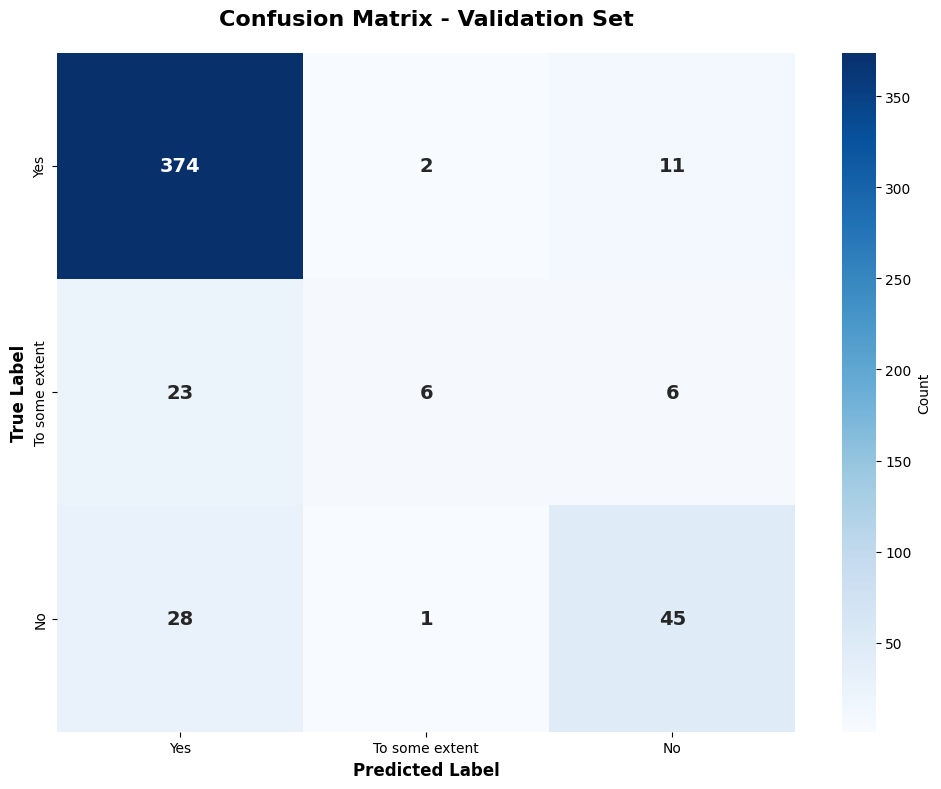


✓ Saved: confusion_matrix_validation.png

Classification Report - Validation Set
                precision    recall  f1-score   support

           Yes     0.8800    0.9664    0.9212       387
To some extent     0.6667    0.1714    0.2727        35
            No     0.7258    0.6081    0.6618        74

      accuracy                         0.8569       496
     macro avg     0.7575    0.5820    0.6186       496
  weighted avg     0.8419    0.8569    0.8367       496



In [30]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

## 12. Make Predictions on Dev and Test Sets (No Labels)


MAKING PREDICTIONS ON DEV & TEST SETS

Predicting on Dev set...
✓ Dev predictions saved to: dev_predictions.csv (333 samples)

Predicting on Test set...
✓ Dev predictions saved to: dev_predictions.csv (333 samples)

Predicting on Test set...
✓ Test predictions saved to: test_predictions.csv (1214 samples)

Prediction Distribution

Dev Set:
Yes               274
No                 54
To some extent      5
Name: count, dtype: int64

Test Set:
Yes               1003
No                 182
To some extent      29
Name: count, dtype: int64
✓ Test predictions saved to: test_predictions.csv (1214 samples)

Prediction Distribution

Dev Set:
Yes               274
No                 54
To some extent      5
Name: count, dtype: int64

Test Set:
Yes               1003
No                 182
To some extent      29
Name: count, dtype: int64


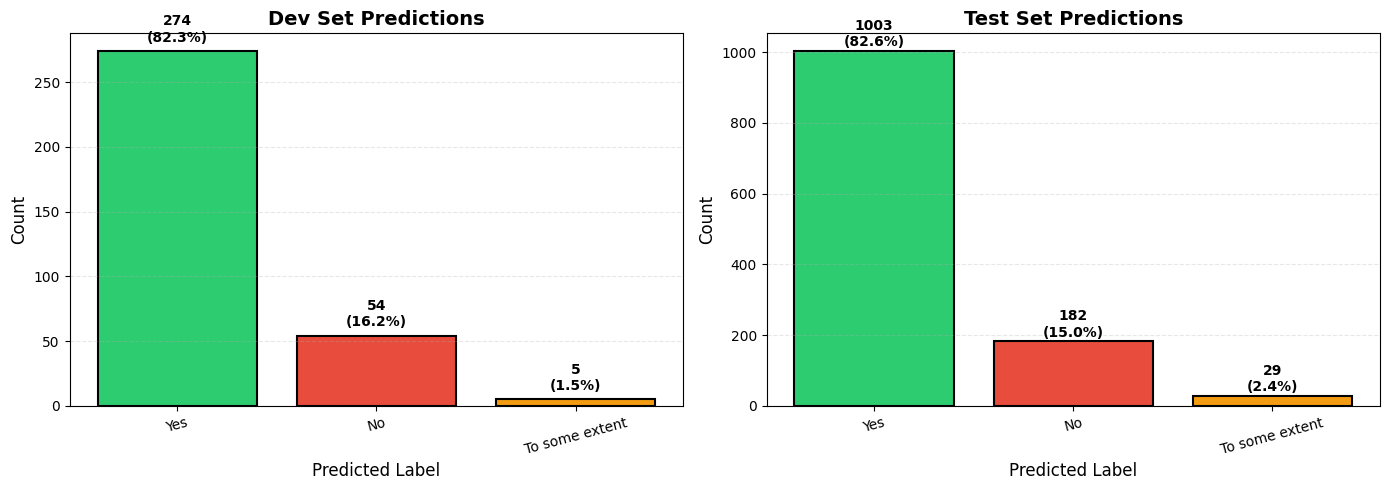


✓ Saved: prediction_distributions.png

Sample Predictions (Dev Set - First 5)

Sample 1:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: No she got 5 gift cards and in total 15 thank you cards. The 15 make up 30% of the class. How many s...
  Predicted: No
  Confidence: 0.838
  ------------------------------------------------------------

Sample 2:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: Let's reconsider the calculation for the number of thank you cards; if she got 5 gift cards, and 1/3...
  Predicted: No
  Confidence: 0.838
  ------------------------------------------------------------

Sample 3:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: I see where you're coming from, but remember, we already determined 

In [31]:
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON DEV & TEST SETS")
print(f"{'='*60}\n")

# Make predictions on dev set
print("Predicting on Dev set...")
dev_predictions = trainer.predict(dev_dataset)
dev_pred_labels = np.argmax(dev_predictions.predictions, axis=1)
dev_pred_probs = torch.softmax(torch.tensor(dev_predictions.predictions), dim=1).numpy()

# Add predictions to dev dataframe
dev_results_df = dev_df.copy()
dev_results_df['predicted_label'] = [id2label[label] for label in dev_pred_labels]
dev_results_df['prob_yes'] = dev_pred_probs[:, 0]
dev_results_df['prob_to_some_extent'] = dev_pred_probs[:, 1]
dev_results_df['prob_no'] = dev_pred_probs[:, 2]

# Save dev predictions
dev_results_df.to_csv('dev_predictions.csv', index=False)
print(f"✓ Dev predictions saved to: dev_predictions.csv ({len(dev_results_df)} samples)")

# Make predictions on test set
print("\nPredicting on Test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_pred_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

# Add predictions to test dataframe
test_results_df = test_df.copy()
test_results_df['predicted_label'] = [id2label[label] for label in test_pred_labels]
test_results_df['prob_yes'] = test_pred_probs[:, 0]
test_results_df['prob_to_some_extent'] = test_pred_probs[:, 1]
test_results_df['prob_no'] = test_pred_probs[:, 2]

# Save test predictions
test_results_df.to_csv('test_predictions.csv', index=False)
print(f"✓ Test predictions saved to: test_predictions.csv ({len(test_results_df)} samples)")

# Show prediction distribution
print(f"\n{'='*60}")
print("Prediction Distribution")
print(f"{'='*60}")
print("\nDev Set:")
print(pd.Series([id2label[label] for label in dev_pred_labels]).value_counts())
print("\nTest Set:")
print(pd.Series([id2label[label] for label in test_pred_labels]).value_counts())

# Visualize prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (pred_labels, name) in enumerate([(dev_pred_labels, 'Dev'), (test_pred_labels, 'Test')]):
    pred_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()
    colors = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
              for label in pred_counts.index]
    bars = axes[idx].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{name} Set Predictions', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, count in zip(bars, pred_counts.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 5,
                      f'{count}\n({count/len(pred_labels)*100:.1f}%)',
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: prediction_distributions.png")

# Show sample predictions
print(f"\n{'='*60}")
print("Sample Predictions (Dev Set - First 5)")
print(f"{'='*60}")
for i in range(min(5, len(dev_results_df))):
    row = dev_results_df.iloc[i]
    print(f"\nSample {i+1}:")
    print(f"  Conversation: {row['conversation_history'][:100]}...")
    print(f"  Tutor Response: {row['tutor_response'][:100]}...")
    print(f"  Predicted: {row['predicted_label']}")
    print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
    print(f"  {'-'*60}")

## 13. Training Summary & Results


TRAINING SUMMARY
Model: microsoft/deberta-v3-large
Training samples: 1980
Validation samples: 496

Validation Set Performance:
  Accuracy: 0.8569
  F1 (Macro): 0.6186
  F1 (Weighted): 0.8367

Per-Class F1 Scores:
  Yes: 0.9212
  To some extent: 0.2727
  No: 0.6618

PREDICTIONS GENERATED
✓ Dev set: 333 predictions → dev_predictions.csv
✓ Test set: 1214 predictions → test_predictions.csv



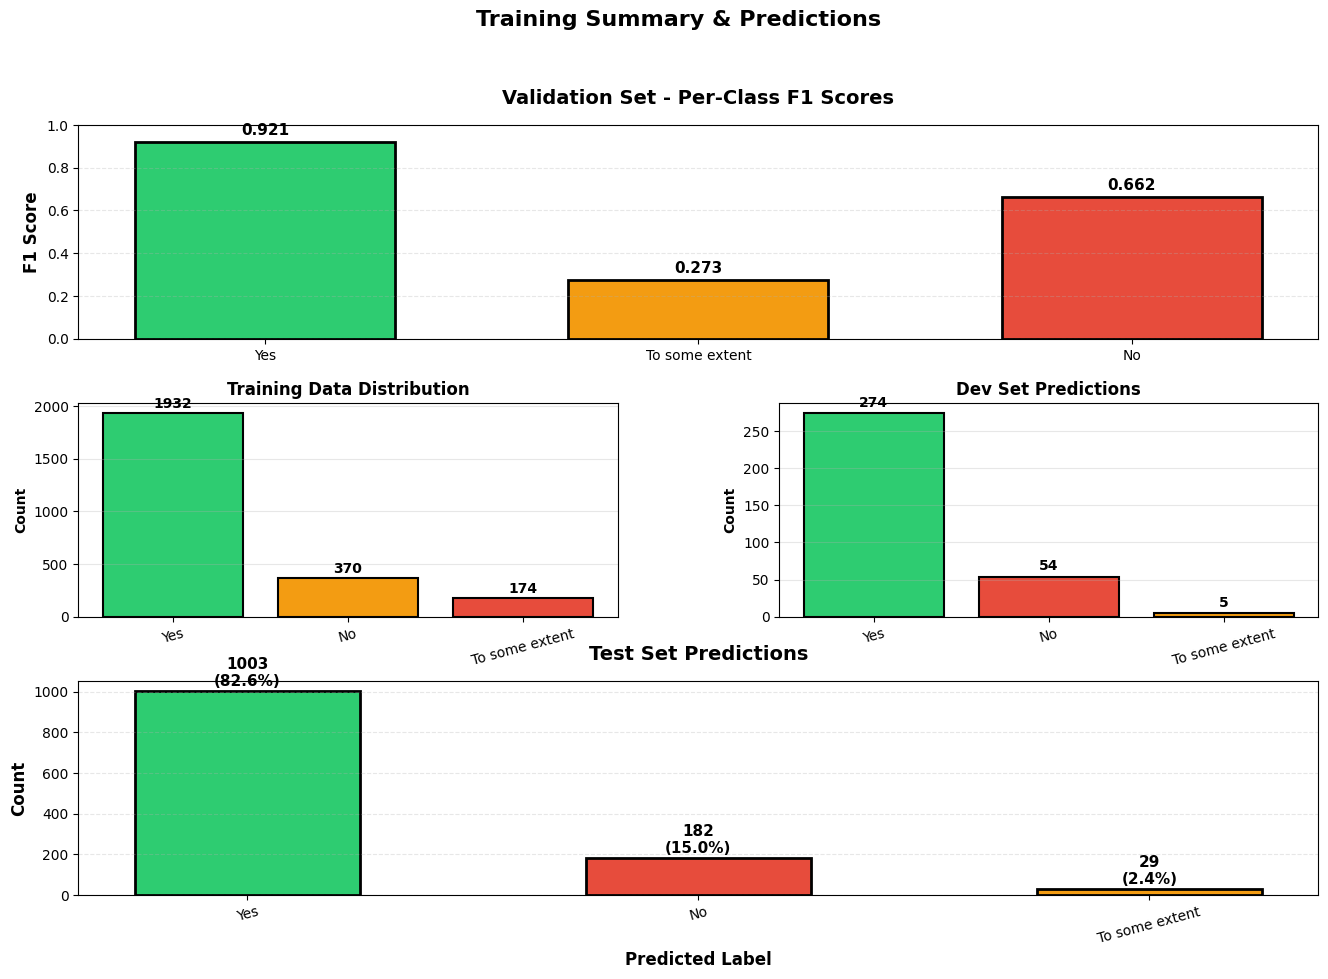

✓ Training summary visualization saved to: training_summary.png


In [32]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions.csv")
print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions.csv")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 3. Dev Set Predictions
ax3 = fig.add_subplot(gs[1, 1])
dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in dev_pred_counts.index]
bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, dev_pred_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 4. Test Set Predictions
ax4 = fig.add_subplot(gs[2, :])
test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in test_pred_counts.index]
bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, test_pred_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
            f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [33]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - best_model/mistake-identification/ → Trained model & tokenizer")
print(f"  - dev_predictions.csv → Dev set predictions with probabilities")
print(f"  - test_predictions.csv → Test set predictions with probabilities")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions.png → Pred distributions for dev/test")
print(f"  - training_summary.png → Complete training summary")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Use model for inference on new conversations")
print(f"  4. Fine-tune if needed based on domain feedback")

print(f"\n{'='*80}\n")


🎉 TRAINING & PREDICTION COMPLETE!

✅ Model trained successfully on 1980 samples
✅ Validation F1-Macro: 0.6186
✅ Predictions generated for 333 dev samples
✅ Predictions generated for 1214 test samples

📁 Output Files:
  - best_model/mistake-identification/ → Trained model & tokenizer
  - dev_predictions.csv → Dev set predictions with probabilities
  - test_predictions.csv → Test set predictions with probabilities
  - confusion_matrix_validation.png → Validation confusion matrix
  - prediction_distributions.png → Pred distributions for dev/test
  - training_summary.png → Complete training summary
  - label_distribution.png → Training data distribution

📊 Next Steps:
  1. Review predictions in CSV files
  2. Analyze model confidence scores (probabilities)
  3. Use model for inference on new conversations
  4. Fine-tune if needed based on domain feedback




## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-base (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `conversation_history` - Original conversation
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Use the model for real-time inference
3. Fine-tune on additional labeled data if available
4. Deploy for production use